<a href="https://colab.research.google.com/github/livlutz/INF1032/blob/main/INF1032.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Este notebook realiza uma Análise Exploratória de Dados (EDA) de um dataset de classificação estelar. O objetivo é compreender as características do dataset, identificar padrões, avaliar a qualidade dos dados e preparar o terreno para futuras tarefas de classificação.

# INF1032 Análise exploratória inicial

**Grupo 1**

Nome: Laís Corbellini Fagundes - 1720482

Nome: Lena Haouas - 2611532

Nome: Lívia Lutz dos Santos - 2211055

Nome: Victor Sequerra Feldman  - 2410943


## Importação de Bibliotecas e Configuração do Ambiente
Esta célula importa as bibliotecas necessárias para a análise, como `pandas` para manipulação de dados, `numpy` para operações numéricas, `matplotlib` e `seaborn` para visualização, `scipy` para testes estatísticos, `plotly` para gráficos interativos e `sklearn` para pré-processamento e PCA. Além disso, são configurados os estilos de plotagem e as opções de exibição do pandas para melhor visualização dos dados.

In [ ]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
warnings.filterwarnings('ignore')

# Configuração de visualização com tratamento de erro
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    # Fallback para versões mais antigas ou mais novas
    try:
        plt.style.use('seaborn-darkgrid')
    except:
        plt.style.use('default')

# Configurações consolidadas do matplotlib
sns.set_palette('husl')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 100,
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9
})

# Configuração do pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## Carregamento do Dataset
Esta célula realiza o download e o carregamento do dataset `stellar_classification.csv` a partir de um link do Google Drive diretamente para um DataFrame pandas. A URL é configurada para permitir o download direto do arquivo.

In [ ]:

# Uploading dataset

# To get a direct download link for a Google Drive file, you typically need to extract the file ID
# and then construct a direct download URL. The file ID for your link is '1nB0MUu_1QDjo6vfVUiGLoI6fdi3KhMlY'.
# A common direct download pattern is 'https://drive.google.com/uc?export=download&id=FILE_ID'.


#PLEASE USE THIS INSTEAD!!!! if it doesn't work lmk

url = "https://drive.google.com/uc?export=download&id=1nB0MUu_1QDjo6vfVUiGLoI6fdi3KhMlY"
stellar_classification = pd.read_csv(url)


## Análise Exploratória Inicial
Esta seção dá início à análise exploratória, apresentando um título para a fase de EDA.

## Visão Geral e Qualidade dos Dados
Esta célula exibe informações essenciais sobre o dataset, como o tipo de dados de cada coluna (`stellar_classification.info()`), um resumo estatístico (`stellar_classification.describe()`), o formato do dataset (`shape`), as colunas presentes e as primeiras linhas (`head()`). Em seguida, é realizada uma verificação da qualidade dos dados, identificando valores ausentes e linhas duplicadas, além de analisar o balanceamento das classes estelares.

In [ ]:
print("⭐ Dataset carregado com sucesso!")

# General information about the dataset
print("\nInformações do dataset:")
stellar_classification.info()

# Statistical resume
print("\nResumo estatístico:")
display(stellar_classification.describe())

# Primeira visualização
print(f"\nShape: {stellar_classification.shape}")
print(f"Colunas: {list(stellar_classification.columns)}")
print(f"\nPrimeiras observações:")
display(stellar_classification.head())

# @title
print("🔍 QUALIDADE DOS DADOS")
print("=" * 50)

# Valores ausentes
missing = stellar_classification.isnull().sum()
print(f"\n❌ Valores ausentes:")
if missing.sum() == 0:
    print("  ✅ Nenhum valor ausente encontrado!")
else:
    print(missing[missing > 0])

# Duplicatas
duplicatas = stellar_classification.duplicated().sum()
print(f"\n🔄 Linhas duplicadas: {duplicatas}")
if duplicatas > 0:
    print(f"  ⚠️ {duplicatas} linhas duplicadas encontradas")

# Balanceamento das classes
print(f"\n⚖️ Distribuição das espécies:")
species_counts = stellar_classification['class'].value_counts()
for species, count in species_counts.items():
    pct = (count / len(stellar_classification)) * 100
    print(f"  {species}: {count} ({pct:.1f}%)")

if species_counts.std() < 1:
    print("  ✅ Dataset perfeitamente balanceado!")

⭐ Dataset carregado com sucesso!

Informações do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   object_ID       100000 non-null  float64
 1   alpha           99999 non-null   object 
 2   delta           99998 non-null   float64
 3   UV_filter       100000 non-null  float64
 4   green_filter    100000 non-null  float64
 5   red_filter      100000 non-null  float64
 6   near_IR_filter  100000 non-null  float64
 7   IR_filter       100000 non-null  float64
 8   run_ID          99994 non-null   object 
 9   rerun_ID        100000 non-null  int64  
 10  cam_col         100000 non-null  int64  
 11  field_ID        100000 non-null  int64  
 12  spec_obj_ID     100000 non-null  float64
 13  red_shift       100000 non-null  float64
 14  plate_ID        100000 non-null  int64  
 15  MJD             100000 non-null  int64  
 16 

,object_ID,delta,UV_filter,green_filter,red_filter,near_IR_filter,IR_filter,rerun_ID,cam_col,field_ID,spec_obj_ID,red_shift,plate_ID,MJD,fiber_ID
count,1.000000e+05,99998.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.240000e+18,24.134955,21.980468,20.531387,19.645762,19.084854,18.668810,301.0,3.511610,186.130520,5.783925e+18,0.576661,5137.009660,55588.647500,449.312740
std,3.020047e+06,19.644480,31.769291,31.750292,1.854760,1.757895,31.728152,0.0,1.586912,149.011073,3.324007e+18,0.730707,2952.303351,1808.484233,272.498404
min,1.240000e+18,-18.785328,-9999.000000,-9999.000000,9.822070,9.469903,-9999.000000,301.0,1.000000,11.000000,3.000000e+17,-0.009971,266.000000,51608.000000,1.000000
25%,1.240000e+18,5.146668,20.352353,18.965230,18.135828,17.732285,17.460677,301.0,2.000000,82.000000,2.840000e+18,0.054517,2526.000000,54234.000000,221.000000
50%,1.240000e+18,23.645922,22.179135,21.099835,20.125290,19.405145,19.004595,301.0,4.000000,146.000000,5.610000e+18,0.424173,4987.000000,55868.500000,433.000000
75%,1.240000e+18,39.901442,23.687440,22.123767,21.044785,20.396495,19.921120,301.0,5.000000,241.000000,8.330000e+18,0.704154,7400.250000,56777.000000,645.000000
max,1.240000e+18,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,301.0,6.000000,989.000000,1.410000e+19,7.011245,12547.000000,58932.000000,1000.000000



Shape: (100000, 18)
Colunas: ['object_ID', 'alpha', 'delta', 'UV_filter', 'green_filter', 'red_filter', 'near_IR_filter', 'IR_filter', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'red_shift', 'plate_ID', 'MJD', 'fiber_ID', 'class']

Primeiras observações:


,object_ID,alpha,delta,UV_filter,green_filter,red_filter,near_IR_filter,IR_filter,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,red_shift,plate_ID,MJD,fiber_ID,class
0,1.240000e+18,135.6891066,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.540000e+18,0.634794,5812,56354,171,GALAXY
1,1.240000e+18,144.8261006,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.180000e+19,0.779136,10445,58158,427,GALAXY
2,1.240000e+18,142.1887896,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.150000e+18,0.644195,4576,55592,299,GALAXY
3,1.240000e+18,338.7410378,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030000e+19,0.932346,9149,58039,775,GALAXY
4,1.240000e+18,345.2825932,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,NaN,301,3,137,6.890000e+18,0.116123,6121,56187,842,GALAXY


🔍 QUALIDADE DOS DADOS

❌ Valores ausentes:
alpha     1
delta     2
run_ID    6
dtype: int64

🔄 Linhas duplicadas: 0

⚖️ Distribuição das espécies:
  GALAXY: 59445 (59.4%)
  STAR: 21594 (21.6%)
  QSO: 18961 (19.0%)


In [ ]:
pip install missingno

## Análise de Valores Ausentes
Esta seção foca na análise e visualização de valores ausentes, utilizando `pandas`, `seaborn` e a biblioteca `missingno` para identificar padrões e a extensão da incompletude dos dados.

In [ ]:
import missingno as msno

# Verificando a quantidade de valores ausentes por coluna
missing_values = stellar_classification.isnull().sum()
missing_percent = (missing_values / len(stellar_classification)) * 100

# Criando um DataFrame para visualização
missing_df = pd.DataFrame({
    'Total Ausentes': missing_values,
    'Percentual (%)': missing_percent
})

print("\nResumo de valores ausentes por coluna:")
print(missing_df[missing_df['Total Ausentes'] > 0].sort_values('Percentual (%)', ascending=False))


Resumo de valores ausentes por coluna:
        Total Ausentes  Percentual (%)
run_ID               6           0.006
delta                2           0.002
alpha                1           0.001


## Tratamento de Valores Ausentes
Nesta seção, vamos tratar os valores ausentes identificados nas colunas `alpha`, `delta` e `run_ID`. Para `delta`, que é numérica, usaremos a média para imputação. Para `alpha` e `run_ID`, que são do tipo 'object' (provavelmente categóricas), utilizaremos a moda para imputação.

In [ ]:
# Imputando valores ausentes

# Coluna 'delta': numérica, imputar com a média
if stellar_classification['delta'].isnull().any():
    delta_mean = stellar_classification['delta'].mean()
    stellar_classification['delta'].fillna(delta_mean, inplace=True)
    print(f"Valores ausentes em 'delta' imputados com a média: {delta_mean:.3f}")

# Colunas 'alpha' e 'run_ID': object, imputar com a moda
for col in ['alpha', 'run_ID']:
    if stellar_classification[col].isnull().any():
        col_mode = stellar_classification[col].mode()[0] # mode() pode retornar múltiplos valores, pegamos o primeiro
        stellar_classification[col].fillna(col_mode, inplace=True)
        print(f"Valores ausentes em '{col}' imputados com a moda: {col_mode}")

print("\nVerificando valores ausentes após imputação:")
missing_after_imputation = stellar_classification.isnull().sum()
if missing_after_imputation.sum() == 0:
    print("✅ Todos os valores ausentes foram tratados!")
else:
    print(missing_after_imputation[missing_after_imputation > 0])

# Exibir informações do dataset para confirmar tipos e não-nulos
print("\nInformações atualizadas do dataset:")
stellar_classification.info()

Valores ausentes em 'delta' imputados com a média: 24.135
Valores ausentes em 'alpha' imputados com a moda: 34.74960002
Valores ausentes em 'run_ID' imputados com a moda: 3225

Verificando valores ausentes após imputação:
✅ Todos os valores ausentes foram tratados!

Informações atualizadas do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   object_ID       100000 non-null  float64
 1   alpha           100000 non-null  object 
 2   delta           100000 non-null  float64
 3   UV_filter       100000 non-null  float64
 4   green_filter    100000 non-null  float64
 5   red_filter      100000 non-null  float64
 6   near_IR_filter  100000 non-null  float64
 7   IR_filter       100000 non-null  float64
 8   run_ID          100000 non-null  object 
 9   rerun_ID        100000 non-null  int64  
 10  cam_col         100000 non-nul

## Tratamento de Features - Remoção de 'spec_obj_ID'

Conforme discutido, a coluna `spec_obj_ID` será removida do dataset. Esta coluna é um identificador único de objeto espectroscópico e não deve ser utilizada como uma característica preditiva, pois pode levar a vazamento de dados (data leakage) e superajuste do modelo, inflacionando artificialmente as métricas de desempenho.

In [ ]:
# Removendo a coluna 'spec_obj_ID'
if 'spec_obj_ID' in stellar_classification.columns:
    stellar_classification = stellar_classification.drop(columns=['spec_obj_ID'])
    print("Coluna 'spec_obj_ID' removida com sucesso.")
else:
    print("A coluna 'spec_obj_ID' não foi encontrada no DataFrame.")

# Atualizando a lista de features para análises futuras
# Certifique-se de que a lista de features usada nas análises posteriores não contenha 'spec_obj_ID'
features = ['UV_filter', 'green_filter', 'red_filter', 'near_IR_filter', 'IR_filter', 'red_shift']

print("Features atualizadas:")
print(features)

# Exibir as primeiras linhas e informações atualizadas do dataset
print("\nPrimeiras observações após remoção de 'spec_obj_ID':")
display(stellar_classification.head())
print("\nInformações atualizadas do dataset:")
stellar_classification.info()

Coluna 'spec_obj_ID' removida com sucesso.
Features atualizadas:
['UV_filter', 'green_filter', 'red_filter', 'near_IR_filter', 'IR_filter', 'red_shift']

Primeiras observações após remoção de 'spec_obj_ID':


,object_ID,alpha,delta,UV_filter,green_filter,red_filter,near_IR_filter,IR_filter,run_ID,rerun_ID,cam_col,field_ID,red_shift,plate_ID,MJD,fiber_ID,class,red_shift_scaled,u-g,g-r,r-i,i-z
0,1.240000e+18,135.6891066,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,0.634794,5812,56354,171,GALAXY,0.324212,1.60352,1.88029,1.22928,0.37202
1,1.240000e+18,144.8261006,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,0.779136,10445,58158,427,GALAXY,0.546401,1.94571,0.24744,1.41632,-0.44615
2,1.240000e+18,142.1887896,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,0.644195,4576,55592,299,GALAXY,0.338683,2.59918,2.05413,1.26119,0.40030
3,1.240000e+18,338.7410378,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,0.932346,9149,58039,775,GALAXY,0.782240,-1.63974,2.16494,1.10708,1.25444
4,1.240000e+18,345.2825932,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,3225,301,3,137,0.116123,6121,56187,842,GALAXY,-0.474188,1.85690,1.08281,0.52036,0.43250



Informações atualizadas do dataset:
<class 'pandas.core.frame.DataFrame'>
Index: 99999 entries, 0 to 99999
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   object_ID         99999 non-null  float64
 1   alpha             99999 non-null  object 
 2   delta             99999 non-null  float64
 3   UV_filter         99999 non-null  float64
 4   green_filter      99999 non-null  float64
 5   red_filter        99999 non-null  float64
 6   near_IR_filter    99999 non-null  float64
 7   IR_filter         99999 non-null  float64
 8   run_ID            99999 non-null  object 
 9   rerun_ID          99999 non-null  int64  
 10  cam_col           99999 non-null  int64  
 11  field_ID          99999 non-null  int64  
 12  red_shift         99999 non-null  float64
 13  plate_ID          99999 non-null  int64  
 14  MJD               99999 non-null  int64  
 15  fiber_ID          99999 non-null  int64  
 16  class   

lines deleted : 1
Clean dataset : 99999 rows
MEDIDAS DE TENDÊNCIA CENTRAL

Uv Filter:
  Média:   22.081
  Mediana: 22.179
  Moda:    24.635

Green Filter:
  Média:   20.632
  Mediana: 21.100
  Moda:    25.114

Red Filter:
  Média:   19.646
  Mediana: 20.125
  Moda:    24.802

Near Ir Filter:
  Média:   19.085
  Mediana: 19.405
  Moda:    24.362

Ir Filter:
  Média:   18.769
  Mediana: 19.005
  Moda:    22.827

Red Shift:
  Média:   0.577
  Mediana: 0.424
  Moda:    0.000


VISUALIZAÇÃO DAS MEDIDAS DE TENDÊNCIA CENTRAL


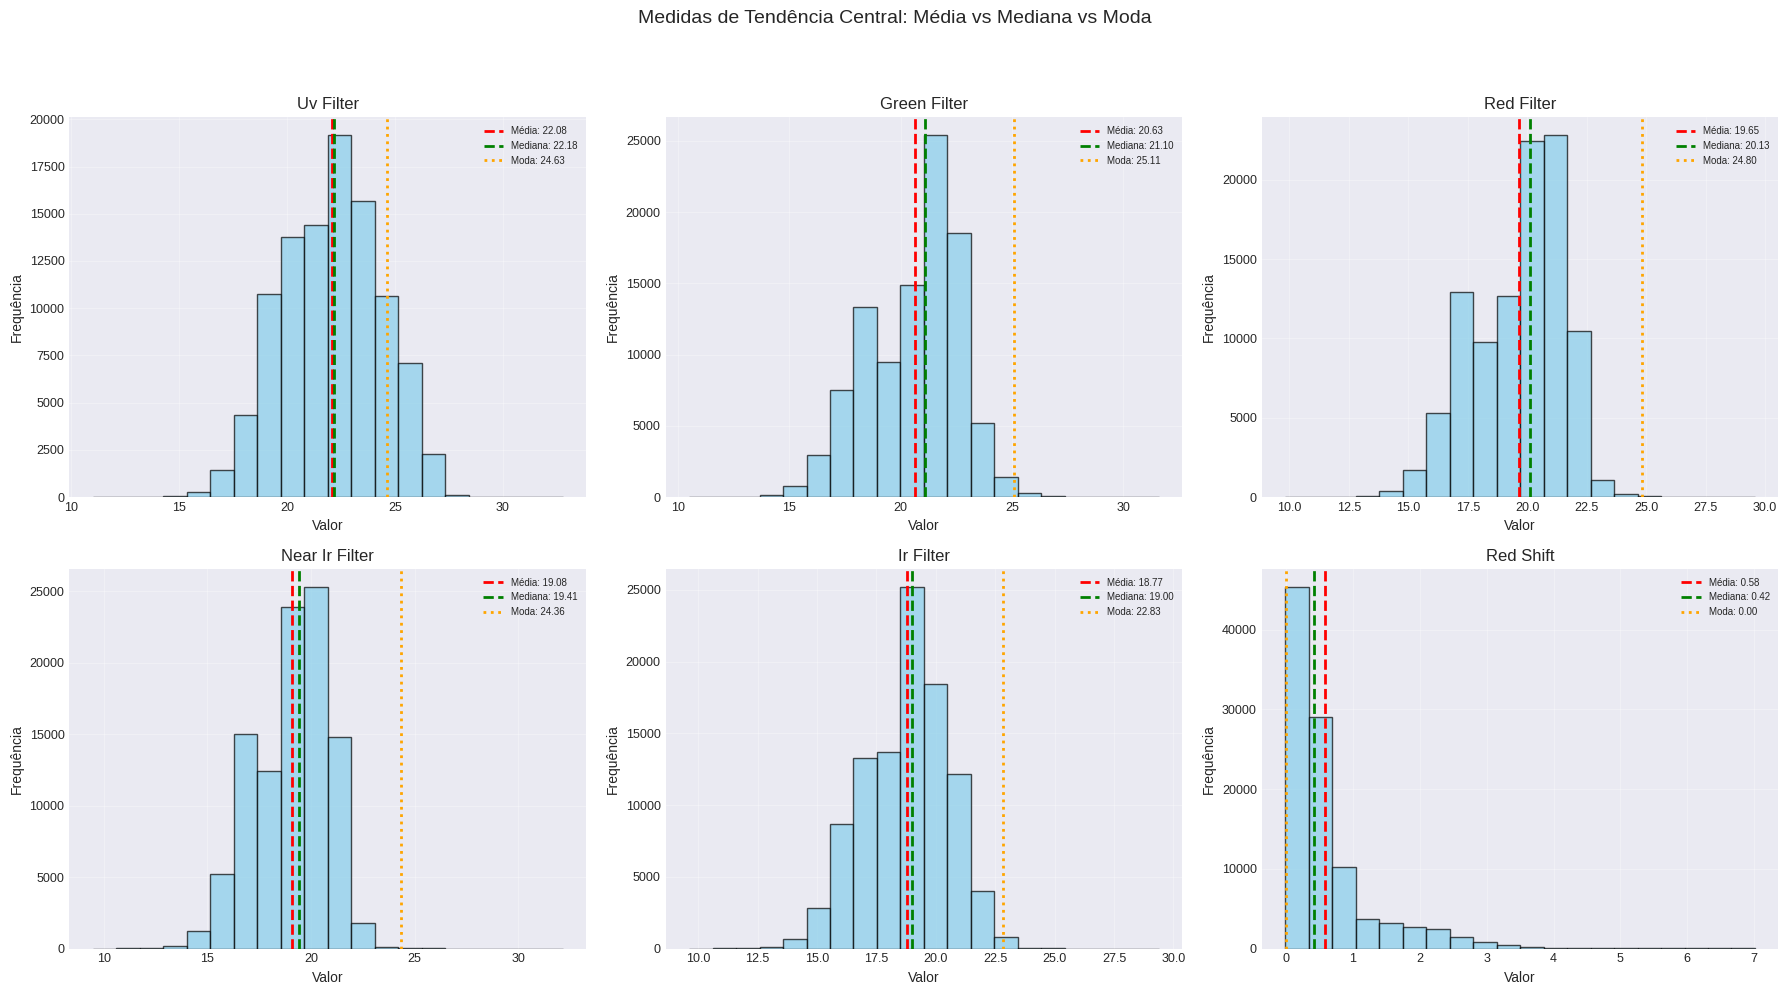

In [ ]:
# Selecting relevant numerical values
features = ['UV_filter', 'green_filter', 'red_filter', 'near_IR_filter', 'IR_filter', 'red_shift']

#Removing -9999 row :
mask_valid = ~(stellar_classification[features].isin([-9999])).any(axis=1)
stellar_classification = stellar_classification[mask_valid]
print(f"lines deleted : {100000 - len(stellar_classification)}")
print(f"Clean dataset : {len(stellar_classification)} rows")

# Calculando as métricas
print("MEDIDAS DE TENDÊNCIA CENTRAL")
print("=" * 40)

for feature in features:
    mean_val = stellar_classification[feature].mean()
    median_val = stellar_classification[feature].median()
    mode_series = stellar_classification[feature].mode()
    mode_val = mode_series[0] if not mode_series.empty else np.nan

    print(f"\n{feature.replace('_', ' ').title()}:")
    print(f"  Média:   {mean_val:.3f}")
    print(f"  Mediana: {median_val:.3f}")
    print(f"  Moda:    {mode_val:.3f}")

# Visualização das medidas de tendência central
print("\n\nVISUALIZAÇÃO DAS MEDIDAS DE TENDÊNCIA CENTRAL")
print("=" * 40)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10)) # Adjusted ncols for 6 features
fig.suptitle('Medidas de Tendência Central: Média vs Mediana vs Moda', fontsize=14, y=1.02)

# Flatten the axes array to easily iterate through them
axes = axes.flatten()

for idx, feature in enumerate(features):
    # Only plot if there are enough axes for the feature
    if idx < len(axes):
        ax = axes[idx]

        # Histograma
        ax.hist(stellar_classification[feature], bins=20, alpha=0.7, color='skyblue', edgecolor='black')

        # Linhas verticais para média, mediana e moda
        mean_val = stellar_classification[feature].mean()
        median_val = stellar_classification[feature].median()
        mode_val = stellar_classification[feature].mode()[0]

        ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Média: {mean_val:.2f}')
        ax.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Mediana: {median_val:.2f}')
        ax.axvline(mode_val, color='orange', linestyle=':', linewidth=2, label=f'Moda: {mode_val:.2f}')

        ax.set_title(feature.replace('_', ' ').title())
        ax.set_xlabel('Valor') # Removed '(cm)'
        ax.set_ylabel('Frequência')
        ax.legend(fontsize=7, loc='upper right')
        ax.grid(True, alpha=0.3)

# Remove any unused subplots if the number of features is less than the total subplots
for i in range(len(features), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

# Tratamento de outliers : Winsorizacao de red_shift
Esta célula aplica a winsorização na variável red_shift para limitar o impacto de valores extremos sem remover observações. A função winsorize de scipy.stats.mstats é utilizada com um limite de 1% em cada extremidade (limits = (0.01, 0.01)), o que faz com que os valores mais extremos sejam ajustados aos percentis 1 e 99. Esse limite conservador foi escolhido porque o red_shift é uma variável fisicamente significativa, essencial para distinguir estrelas, galáxias e quasares. O resultado é armazenado em uma nova coluna chamada red_shift_w, que será posteriormente utilizada como entrada do RobustScaler.


In [ ]:
from scipy.stats.mstats import winsorize
import matplotlib.pyplot as plt

stellar_classification['red_shift_w'] = winsorize(
    stellar_classification['red_shift'], limits=(0.01, 0.01)
)
print("=== Before winsorisation ===")
print(stellar_classification['red_shift'].describe())

print("\n=== After winsorisation ===")
print(stellar_classification['red_shift_w'].describe())


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].boxplot(stellar_classification['red_shift'])
axes[0].set_title('red_shift — Original')

axes[1].boxplot(stellar_classification['red_shift_w'])
axes[1].set_title('red_shift — After winsorisation')

plt.tight_layout()
plt.show()

## Normalização e Escalonamento de Features
Esta célula demonstra a aplicação do `RobustScaler` para normalizar a variável `red_shift`, que possui valores com uma grande amplitude. O `RobustScaler` é escolhido por ser menos sensível a outliers. Em seguida, outras características numéricas relevantes (`UV_filter`, `green_filter`, `red_filter`, `near_IR_filter`, `IR_filter`, `red_shift`) são escaladas para garantir que todas as features contribuam igualmente para análises posteriores, como PCA, evitando que características com grandes escalas dominem o processo.

In [ ]:
#Normalisation of red_shift datas :
# values are huge, so we will use the RobustScaler to scale our datas
from sklearn.preprocessing import RobustScaler
robust_scaler = RobustScaler()

#We scale the columns of our dataset, except the spec_obj_ID
features_to_scale = ['UV_filter', 'green_filter', 'red_filter','near_IR_filter', 'IR_filter', 'red_shift_w']
X_scaled = robust_scaler.fit_transform(stellar_classification[features_to_scale])

# Avant scaling
print("Before scaling:")
display(stellar_classification[features_to_scale].describe().round(3))

# Après scaling
print("\nAfter scaling (RobustScaler):")
X_scaled_df = pd.DataFrame(X_scaled, columns=features_to_scale)
display(X_scaled_df.describe().round(3))

## Medidas de Tendência Central
Esta célula seleciona as características numéricas principais e remove qualquer linha que possa conter o valor '-9999' (considerado um valor inválido). Em seguida, calcula e exibe as medidas de tendência central (média, mediana e moda) para cada uma dessas características. A segunda parte da célula visualiza essas medidas através de histogramas, com linhas verticais indicando a posição da média, mediana e moda, para uma compreensão visual da distribuição dos dados e de sua centralidade.

lines deleted : 1
Clean dataset : 99999 rows
MEDIDAS DE TENDÊNCIA CENTRAL

Uv Filter:
  Média:   22.081
  Mediana: 22.179
  Moda:    24.635

Green Filter:
  Média:   20.632
  Mediana: 21.100
  Moda:    25.114

Red Filter:
  Média:   19.646
  Mediana: 20.125
  Moda:    24.802

Near Ir Filter:
  Média:   19.085
  Mediana: 19.405
  Moda:    24.362

Ir Filter:
  Média:   18.769
  Mediana: 19.005
  Moda:    22.827

Red Shift:
  Média:   0.577
  Mediana: 0.424
  Moda:    0.000


VISUALIZAÇÃO DAS MEDIDAS DE TENDÊNCIA CENTRAL


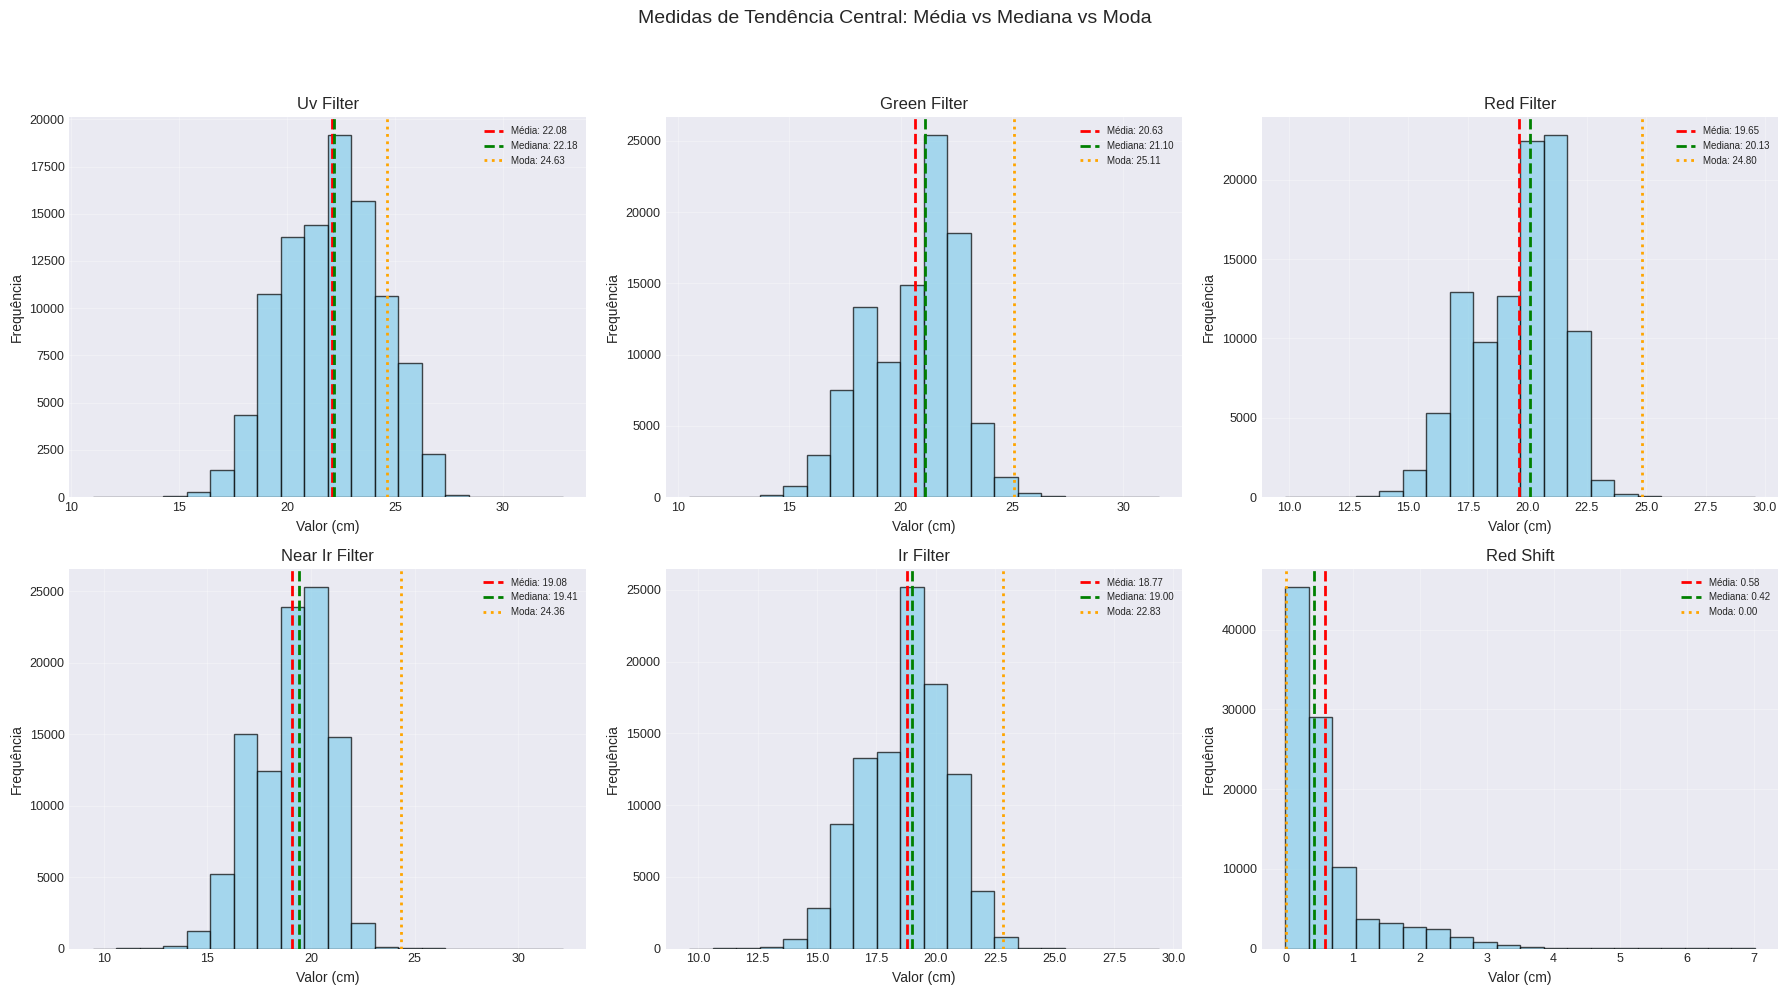

In [ ]:
# Selecting relevant numerical values
features = ['UV_filter', 'green_filter', 'red_filter', 'near_IR_filter', 'IR_filter', 'red_shift']

#Removing -9999 row :
mask_valid = ~(stellar_classification[features_to_scale] == -9999).any(axis=1)
stellar_classification = stellar_classification[mask_valid]
print(f"lines deleted : {100000 - len(stellar_classification)}")
print(f"Clean dataset : {len(stellar_classification)} rows")

# Calculando as métricas
print("MEDIDAS DE TENDÊNCIA CENTRAL")
print("=" * 40)

for feature in features:
    mean_val = stellar_classification[feature].mean()
    median_val = stellar_classification[feature].median()
    mode_series = stellar_classification[feature].mode()
    mode_val = mode_series[0] if not mode_series.empty else np.nan

    print(f"\n{feature.replace('_', ' ').title()}:")
    print(f"  Média:   {mean_val:.3f}")
    print(f"  Mediana: {median_val:.3f}")
    print(f"  Moda:    {mode_val:.3f}")

# Visualização das medidas de tendência central
print("\n\nVISUALIZAÇÃO DAS MEDIDAS DE TENDÊNCIA CENTRAL")
print("=" * 40)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10)) # Adjusted ncols for 6 features
fig.suptitle('Medidas de Tendência Central: Média vs Mediana vs Moda', fontsize=14, y=1.02)

# Flatten the axes array to easily iterate through them
axes = axes.flatten()

for idx, feature in enumerate(features):
    # Only plot if there are enough axes for the feature
    if idx < len(axes):
        ax = axes[idx]

        # Histograma
        ax.hist(stellar_classification[feature], bins=20, alpha=0.7, color='skyblue', edgecolor='black')

        # Linhas verticais para média, mediana e moda
        mean_val = stellar_classification[feature].mean()
        median_val = stellar_classification[feature].median()
        mode_val = stellar_classification[feature].mode()[0]

        ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Média: {mean_val:.2f}')
        ax.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Mediana: {median_val:.2f}')
        ax.axvline(mode_val, color='orange', linestyle=':', linewidth=2, label=f'Moda: {mode_val:.2f}')

        ax.set_title(feature.replace('_', ' ').title())
        ax.set_xlabel('Valor (cm)')
        ax.set_ylabel('Frequência')
        ax.legend(fontsize=7, loc='upper right')
        ax.grid(True, alpha=0.3)

# Remove any unused subplots if the number of features is less than the total subplots
for i in range(len(features), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

## Medidas de Dispersão
Esta célula calcula e exibe as medidas de dispersão para as características selecionadas, incluindo amplitude, variância, desvio padrão e coeficiente de variação. Essas métricas ajudam a entender a variabilidade e a propagação dos dados. A segunda parte da célula visualiza o conceito de desvio padrão usando histogramas, onde são marcadas as faixas de ±1σ, ±2σ e ±3σ em torno da média, ilustrando a regra empírica 68-95-99.7 para distribuições normais e permitindo avaliar a simetria e a dispersão dos dados.

MEDIDAS DE DISPERSÃO

Uv Filter:
  Amplitude:           21.785
  Variância:           5.067
  Desvio Padrão:       2.251
  Coef. de Variação:   10.2%

Green Filter:
  Amplitude:           21.104
  Variância:           4.151
  Desvio Padrão:       2.037
  Coef. de Variação:   9.9%

Red Filter:
  Amplitude:           19.750
  Variância:           3.440
  Desvio Padrão:       1.855
  Coef. de Variação:   9.4%

Near Ir Filter:
  Amplitude:           22.672
  Variância:           3.090
  Desvio Padrão:       1.758
  Coef. de Variação:   9.2%

Ir Filter:
  Amplitude:           19.771
  Variância:           3.119
  Desvio Padrão:       1.766
  Coef. de Variação:   9.4%

Red Shift:
  Amplitude:           7.021
  Variância:           0.534
  Desvio Padrão:       0.731
  Coef. de Variação:   126.7%


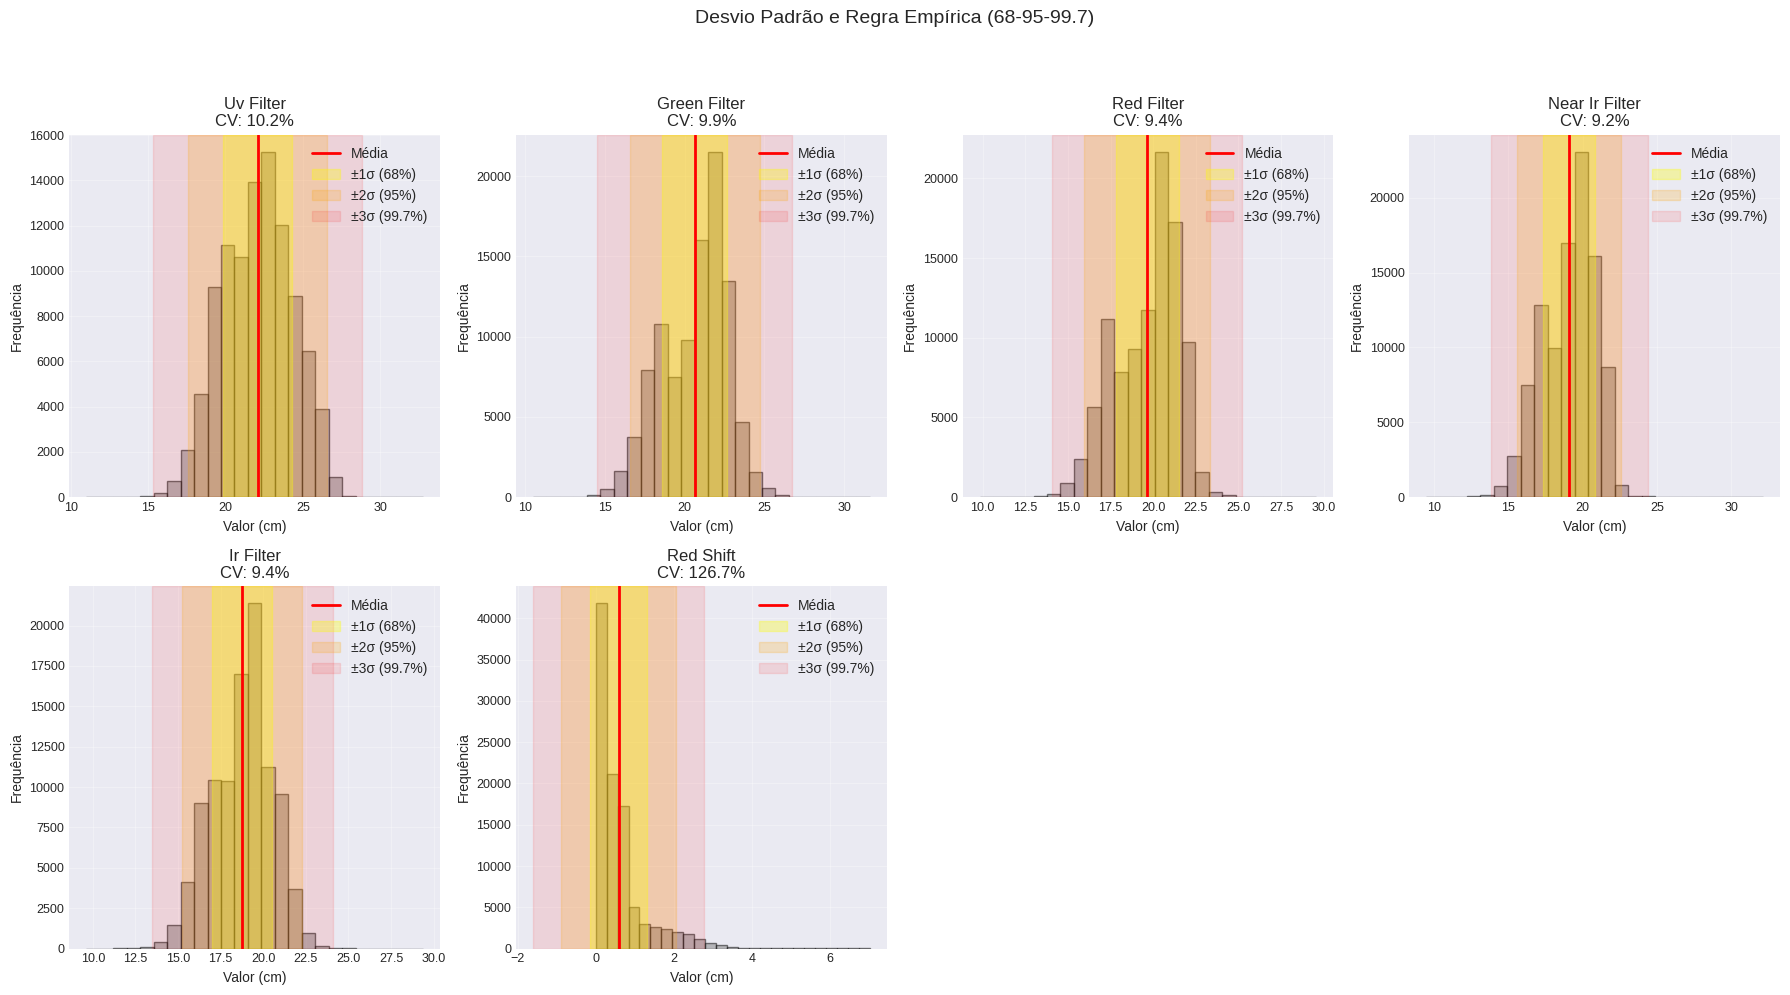

In [ ]:
#Medidas de dispersão
print("MEDIDAS DE DISPERSÃO")
print("=" * 40)

for feature in features:
    amplitude = stellar_classification[feature].max() - stellar_classification[feature].min()
    variancia = stellar_classification[feature].var()
    desvio_padrao = stellar_classification[feature].std()
    coef_variacao = (desvio_padrao / stellar_classification[feature].mean()) * 100

    print(f"\n{feature.replace('_', ' ').title()}:")
    print(f"  Amplitude:           {amplitude:.3f}")
    print(f"  Variância:           {variancia:.3f}")
    print(f"  Desvio Padrão:       {desvio_padrao:.3f}")
    print(f"  Coef. de Variação:   {coef_variacao:.1f}%")


# Visualização do conceito de desvio padrão
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(18, 10))
fig.suptitle('Desvio Padrão e Regra Empírica (68-95-99.7)', fontsize=14, y=1.02)

# "achata" os eixos para iterar facilmente
axes = axes.flatten()

for idx, feature in enumerate(features):
    # Only plot if there are enough axes for the feature
    if idx < len(axes):
        ax = axes[idx]
        mean = stellar_classification[feature].mean()
        std = stellar_classification[feature].std()
        cv = (std/mean) * 100

        # Histograma
        counts, bins, patches = ax.hist(stellar_classification[feature], bins=25, alpha=0.5, color='gray', edgecolor='black')

        # Linha da média
        ax.axvline(mean, color='red', linewidth=2, label='Média', zorder=5)

        # Faixas de desvio padrão
        ax.axvspan(mean-std, mean+std, alpha=0.3, color='yellow', label='±1σ (68%)', zorder=3)
        ax.axvspan(mean-2*std, mean+2*std, alpha=0.2, color='orange', label='±2σ (95%)', zorder=2)
        ax.axvspan(mean-3*std, mean+3*std, alpha=0.1, color='red', label='±3σ (99.7%)', zorder=1)

        ax.set_title(f'{feature.replace("_", " ").title()}\nCV: {cv:.1f}%')
        ax.set_xlabel('Valor (cm)')
        ax.set_ylabel('Frequência')
        ax.legend(fontsize=10, loc='upper right')
        ax.grid(True, alpha=0.3)

# Remove any unused subplots if the number of features is less than the total subplots
for i in range(len(features), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

## Coeficiente de Variação por Classe Estelar
Esta célula calcula o coeficiente de variação (CV) para cada característica numérica, segmentado pelas diferentes classes estelares (GALAXY, QSO, STAR). O CV é uma medida da dispersão relativa e ajuda a comparar a variabilidade entre grupos com diferentes médias. A saída permite identificar quais características apresentam maior ou menor variabilidade dentro de cada classe, fornecendo insights sobre a consistência das medições para cada tipo de objeto celestial.

In [ ]:
# Calculando coeficiente de variação por classe estelar
print("COEFICIENTE DE VARIAÇÃO (%) POR CLASSE ESTELAR")
print("=" * 45)

cv_df = pd.DataFrame(index=features)

for stellar_class in stellar_classification['class'].unique():
    subset = stellar_classification[stellar_classification['class'] == stellar_class]
    cv_values = {}

    for feature in features:
        mean = subset[feature].mean()
        std = subset[feature].std()
        # Handle cases where mean might be zero or very close to zero to avoid division by zero or large CVs due to tiny means
        cv = (std / mean) * 100 if mean != 0 else np.nan  # CV em porcentagem
        cv_values[feature] = cv

    cv_df[stellar_class] = pd.Series(cv_values)

display(cv_df.round(2))

print("\nINTERPRETAÇÃO:")
print("- CV < 10%:  Baixa variabilidade")
print("- CV 10-20%: Média variabilidade")
print("- CV > 20%:  Alta variabilidade")

COEFICIENTE DE VARIAÇÃO (%) POR CLASSE ESTELAR


,GALAXY,QSO,STAR
UV_filter,10.02,6.94,11.16
green_filter,10.08,5.56,10.80
red_filter,9.57,5.26,10.41
near_IR_filter,8.96,5.29,9.93
IR_filter,8.98,5.40,10.05
red_shift,62.82,53.15,-404.82



INTERPRETAÇÃO:
- CV < 10%:  Baixa variabilidade
- CV 10-20%: Média variabilidade
- CV > 20%:  Alta variabilidade


## Medidas de Posição (Quartis e Percentis)
Esta célula calcula e exibe as medidas de posição, como o primeiro quartil (Q1), a mediana (Q2), o terceiro quartil (Q3), o Intervalo Interquartil (IQR), e os percentis 10 (P10) e 90 (P90) para cada característica numérica. Essas medidas são fundamentais para entender a distribuição dos dados, identificar a dispersão dos valores centrais e detectar a presença de valores extremos.

In [ ]:
print("MEDIDAS DE POSIÇÃO")
print("=" * 40)

for feature in features:
    q1 = stellar_classification[feature].quantile(0.25)
    q2 = stellar_classification[feature].quantile(0.50)  # mediana
    q3 = stellar_classification[feature].quantile(0.75)
    iqr = q3 - q1

    p10 = stellar_classification[feature].quantile(0.10)
    p90 = stellar_classification[feature].quantile(0.90)

    print(f"\n{feature.replace('_', ' ').title()}:")
    print(f"  Q1 (25%):     {q1:.3f}")
    print(f"  Q2 (50%):     {q2:.3f}")
    print(f"  Q3 (75%):     {q3:.3f}")
    print(f"  IQR (Q3-Q1): {iqr:.3f}")
    print(f"  P10:          {p10:.3f}")
    print(f"  P90:          {p90:.3f}")

MEDIDAS DE POSIÇÃO

Uv Filter:
  Q1 (25%):     20.352
  Q2 (50%):     22.179
  Q3 (75%):     23.687
  IQR (Q3-Q1): 3.335
  P10:          19.117
  P90:          25.096

Green Filter:
  Q1 (25%):     18.965
  Q2 (50%):     21.100
  Q3 (75%):     22.124
  IQR (Q3-Q1): 3.159
  P10:          17.758
  P90:          22.892

Red Filter:
  Q1 (25%):     18.136
  Q2 (50%):     20.125
  Q3 (75%):     21.045
  IQR (Q3-Q1): 2.909
  P10:          17.010
  P90:          21.763

Near Ir Filter:
  Q1 (25%):     17.732
  Q2 (50%):     19.405
  Q3 (75%):     20.397
  IQR (Q3-Q1): 2.664
  P10:          16.619
  P90:          21.236

Ir Filter:
  Q1 (25%):     17.461
  Q2 (50%):     19.005
  Q3 (75%):     19.921
  IQR (Q3-Q1): 2.460
  P10:          16.342
  P90:          21.008

Red Shift:
  Q1 (25%):     0.055
  Q2 (50%):     0.424
  Q3 (75%):     0.704
  IQR (Q3-Q1): 0.650
  P10:          -0.000
  P90:          1.564


## Visualização de Quartis, IQR e Detecção de Outliers
Esta célula visualiza as medidas de posição calculadas, incluindo quartis e o Intervalo Interquartil (IQR), através de boxplots e histogramas. Os boxplots são usados para representar a distribuição dos dados e identificar potenciais outliers, enquanto os histogramas mostram a frequência dos valores e as linhas dos quartis. Limites de "fence" (cercas) são adicionados para indicar os pontos além dos quais os dados são considerados outliers, baseados na regra de 1.5 * IQR.

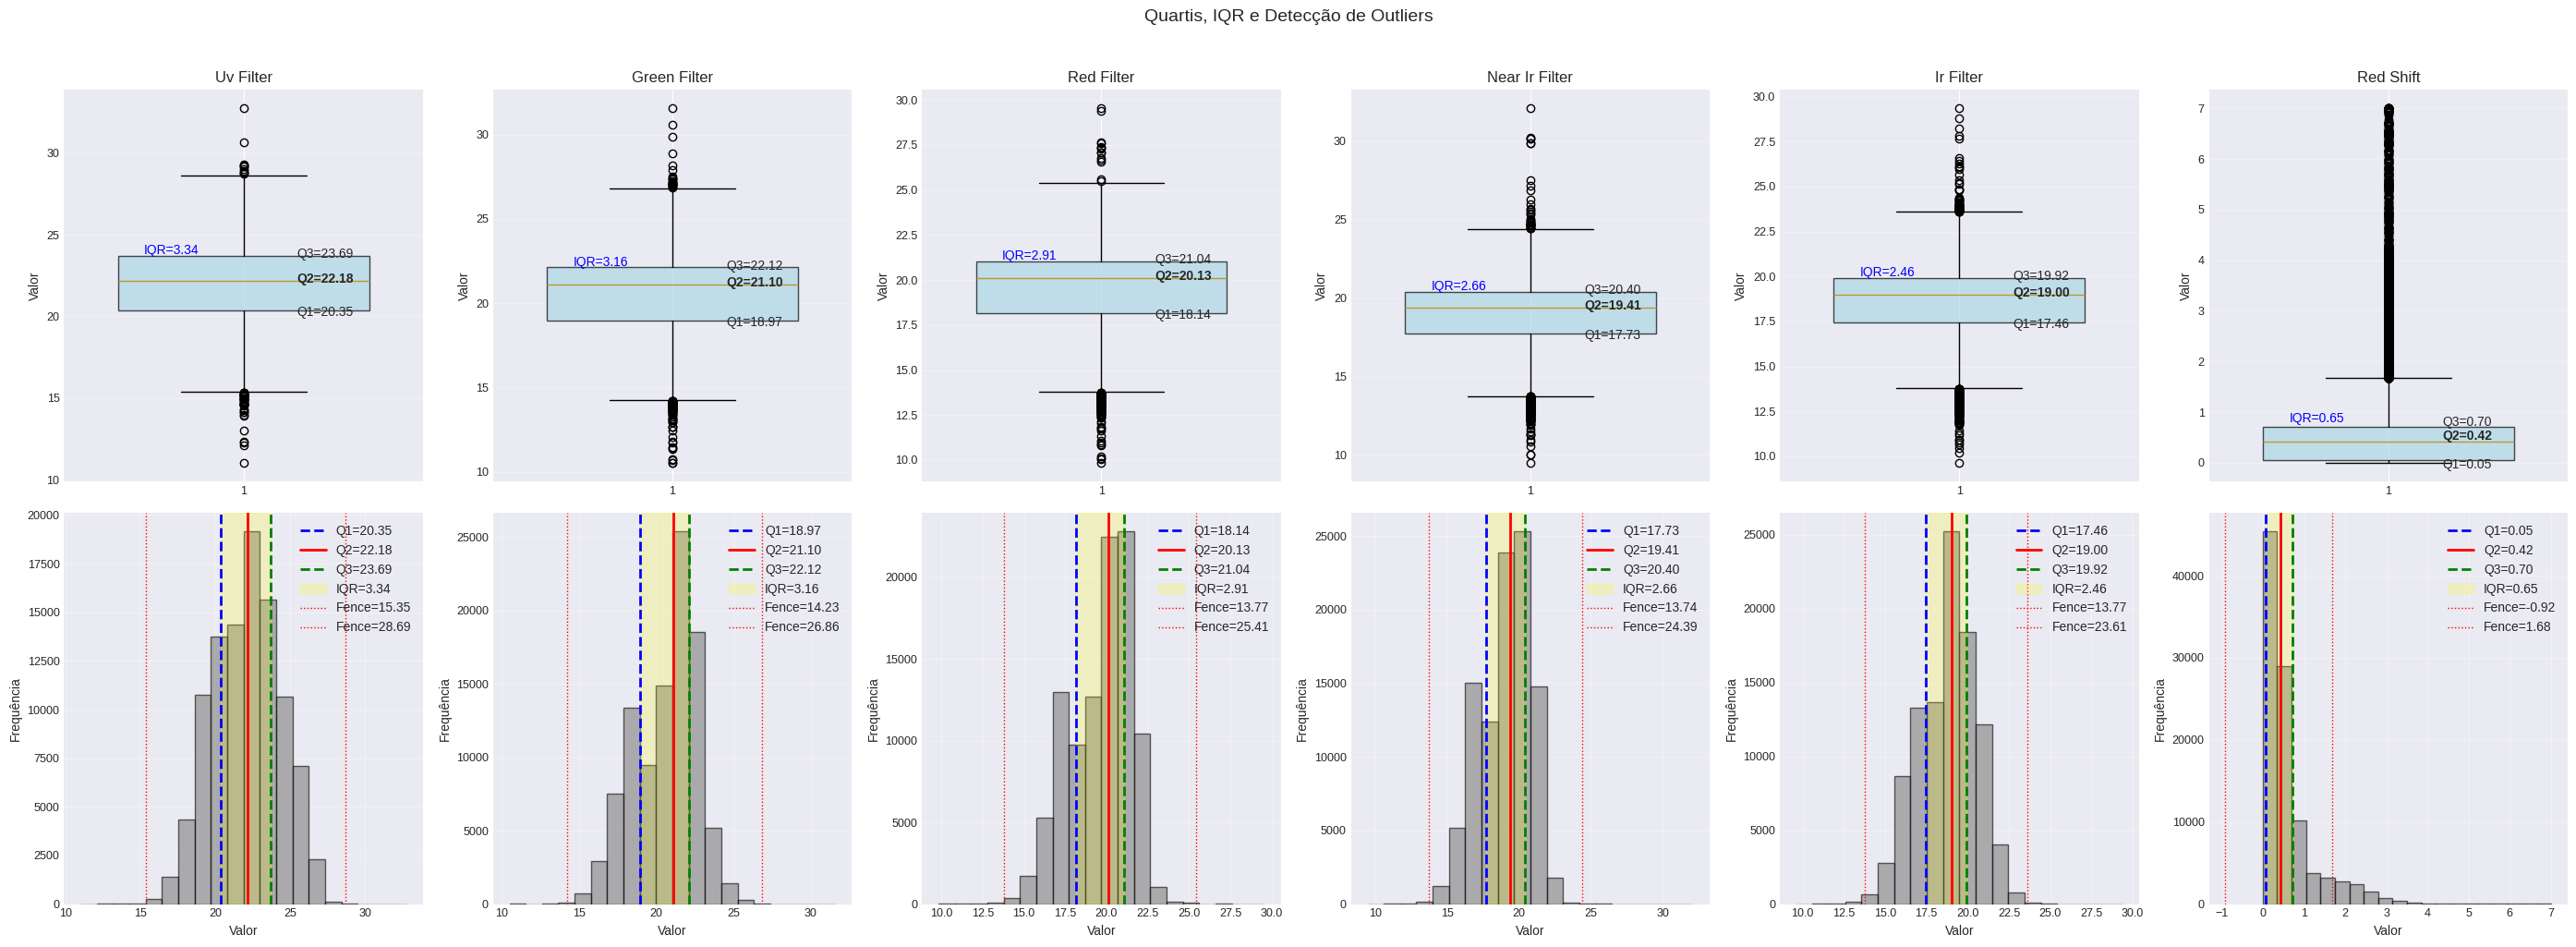

📊 COMPREENDENDO BOXPLOTS:
• Caixa central: IQR (50% central dos dados)
• Linha na caixa: Mediana (Q2)
• Bigodes: Até 1.5×IQR ou valor máximo/mínimo
• Pontos além dos bigodes: Possíveis outliers
• Linhas pontilhadas vermelhas (fence): Limites para detecção de outliers


In [ ]:
# Visualização de Quartis e IQR
# Adjusted ncols to len(features) to accommodate all plots
# Adjusted figsize for better visual appeal with more columns
fig, axes = plt.subplots(2, len(features), figsize=(28, 10))
fig.suptitle('Quartis, IQR e Detecção de Outliers', fontsize=14, y=1.02)

for idx, feature in enumerate(features):
    # Boxplot com anotações
    ax1 = axes[0, idx]
    bp = ax1.boxplot(stellar_classification[feature], vert=True, patch_artist=True, widths=0.7)
    bp['boxes'][0].set_facecolor('lightblue')
    bp['boxes'][0].set_alpha(0.7)

    # Calcular quartis
    q1, q2, q3 = stellar_classification[feature].quantile([0.25, 0.5, 0.75])
    iqr = q3 - q1
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr

    # Adicionar anotações
    ax1.text(1.15, q1-0.1, f'Q1={q1:.2f}', va='center', fontsize=10)
    ax1.text(1.15, q2+0.1, f'Q2={q2:.2f}', va='center', fontsize=10, fontweight='bold')
    ax1.text(1.15, q3+0.1, f'Q3={q3:.2f}', va='center', fontsize=10)
    ax1.text(0.8, q3 +0.1, f'IQR={iqr:.2f}', ha='center', fontsize=10, color='blue')

    ax1.set_title(feature.replace('_', ' ').title())
    # Removed '(cm)' as it is not appropriate for these features
    ax1.set_ylabel('Valor')
    ax1.grid(True, alpha=0.3, axis='y')

    # Histograma com quartis
    ax2 = axes[1, idx]
    ax2.hist(stellar_classification[feature], bins=20, alpha=0.6, color='gray', edgecolor='black')

    # Linhas dos quartis
    ax2.axvline(q1, color='blue', linestyle='--', linewidth=2, label=f'Q1={q1:.2f}')
    ax2.axvline(q2, color='red', linestyle='-', linewidth=2, label=f'Q2={q2:.2f}')
    ax2.axvline(q3, color='green', linestyle='--', linewidth=2, label=f'Q3={q3:.2f}')

    # Área do IQR
    ax2.axvspan(q1, q3, alpha=0.2, color='yellow', label=f'IQR={iqr:.2f}')

    # Limites de outliers (fence)
    ax2.axvline(lower_fence, color='red', linestyle=':', linewidth=1, label=f'Fence={lower_fence:.2f}')
    ax2.axvline(upper_fence, color='red', linestyle=':', linewidth=1, label=f'Fence={upper_fence:.2f}')

    # Removed '(cm)' as it is not appropriate for these features
    ax2.set_xlabel('Valor')
    ax2.set_ylabel('Frequência')
    ax2.legend(fontsize=10, loc='upper right')
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("📊 COMPREENDENDO BOXPLOTS:")
print("• Caixa central: IQR (50% central dos dados)")
print("• Linha na caixa: Mediana (Q2)")
print("• Bigodes: Até 1.5×IQR ou valor máximo/mínimo")
print("• Pontos além dos bigodes: Possíveis outliers")
print("• Linhas pontilhadas vermelhas (fence): Limites para detecção de outliers")

## Estatísticas Descritivas por Classe Estelar
Esta célula calcula e exibe estatísticas descritivas completas para cada característica numérica, agrupadas por classe estelar (GALAXY, QSO, STAR). Isso permite comparar diretamente as propriedades estatísticas (média, desvio padrão, quartis, etc.) de cada tipo de objeto celestial. Em seguida, são mostradas as médias específicas para cada característica, facilitando a identificação das diferenças centrais entre as classes.

In [ ]:
# Estatísticas descritivas por classe estelar
print("ESTATÍSTICAS POR CLASSE ESTELAR")
print("=" * 50)

stats_by_class = stellar_classification.groupby('class').describe()
display(stats_by_class)

print("\nMÉDIAS POR CLASSE ESTELAR:")
means_by_class = stellar_classification.groupby('class')[features].mean()
display(means_by_class.round(3))

ESTATÍSTICAS POR CLASSE ESTELAR


object_ID                                                           \
           count          mean            std           min           25%   
class                                                                       
GALAXY   59445.0  1.240000e+18  253698.133899  1.240000e+18  1.240000e+18   
QSO      18961.0  1.240000e+18  235782.217640  1.240000e+18  1.240000e+18   
STAR     21593.0  1.240000e+18  239109.536801  1.240000e+18  1.240000e+18   

                                                    delta             \
                 50%           75%           max    count       mean   
class                                                                  
GALAXY  1.240000e+18  1.240000e+18  1.240000e+18  59445.0  23.513972   
QSO     1.240000e+18  1.240000e+18  1.240000e+18  18961.0  26.806587   
STAR    1.240000e+18  1.240000e+18  1.240000e+18  21593.0  23.499671   

                                                                         \
              std        min       25%        50%        75%        max   
class                                                                     
GALAXY  19.315201 -12.364701  5.167016  22.302639  37.972697  77.615588   
QSO     19.586685 -15.980904  7.427090  29.289525  42.886423  82.288657   
STAR    20.383099 -18.785328  3.128794  23.400590  39.939759  83.000519   

       UV_filter                                                               \
           count       mean       std       min       25%       50%       75%   
class                                                                           
GALAXY   59445.0  22.587379  2.264355  13.89799  20.79476  22.84177  24.20741   
QSO      18961.0  21.547619  1.495879  10.99623  20.63764  21.50324  22.28647   
STAR     21593.0  21.153830  2.360482  12.10168  19.32774  21.01065  22.96063   

                 green_filter                                           \
             max        count       mean       std       min       25%   
class                                                                    
GALAXY  29.32565      59445.0  20.906101  2.107755  12.67902  18.91268   
QSO     32.78139      18961.0  20.926193  1.163239  13.66217  20.24973   
STAR    30.66039      21593.0  19.617142  2.119478  10.49820  18.03487   

                                     red_filter                       \
             50%       75%       max      count       mean       std   
class                                                                  
GALAXY  21.58220  22.44513  31.60224    59445.0  19.587552  1.874133   
QSO     21.05629  21.68777  27.89482    18961.0  20.624089  1.084237   
STAR    19.54283  21.22877  30.60700    21593.0  18.947005  1.972825   

                                                         near_IR_filter  \
             min       25%       50%       75%       max          count   
class                                                                     
GALAXY  11.74664  17.81715  20.10459  20.97461  29.57186        59445.0   
QSO     12.35763  20.00633  20.77272  21.41345  27.39709        18961.0   
STAR     9.82207  17.45395  18.95513  20.55757  29.37411        21593.0   

                                                                      \
             mean       std        min       25%       50%       75%   
class                                                                  
GALAXY  18.851990  1.689809  11.299560  17.37967  19.22366  19.94709   
QSO     20.431173  1.080135  12.637440  19.81107  20.58211  21.20228   
STAR    18.543760  1.841753   9.469903  17.13960  18.59239  20.04198   

                 IR_filter                                            \
             max     count       mean       std        min       25%   
class                                                                  
GALAXY  30.16359   59445.0  18.449156  1.656302  10.897380  17.09567   
QSO     32.14147   18961.0  20.266732  1.095076  11.302470  19.64425   
STAR    30.25009   21593.0  18.334295  1.843201   9


MÉDIAS POR CLASSE ESTELAR:


,UV_filter,green_filter,red_filter,near_IR_filter,IR_filter,red_shift
class,,,,,,
GALAXY,22.587,20.906,19.588,18.852,18.449,0.422
QSO,21.548,20.926,20.624,20.431,20.267,1.720
STAR,21.154,19.617,18.947,18.544,18.334,-0.000


## Matriz de Correlação
Esta célula calcula a matriz de correlação de Pearson para as características numéricas selecionadas. A matriz de correlação mede a força e a direção da relação linear entre pares de variáveis. Além de exibir a matriz completa, a célula identifica e lista os pares de características com as correlações mais fortes, o que é crucial para entender a interdependência entre as variáveis e identificar possível multicolinearidade.

In [ ]:
# Calculando matriz de correlação
correlation_matrix = stellar_classification[features].corr()

print("MATRIZ DE CORRELAÇÃO (Pearson)")
print("=" * 40)
display(correlation_matrix.round(3))

# Identificando correlações mais fortes
print("\nCORRELAÇÕES MAIS FORTES:")
print("-" * 30)

# Extrair pares únicos (triangular superior)
mask = np.triu(np.ones_like(correlation_matrix), k=1).astype(bool)
correlations = correlation_matrix.where(mask).stack().reset_index()
correlations.columns = ['Var1', 'Var2', 'Correlacao']
correlations = correlations.sort_values('Correlacao', key=abs, ascending=False)

for _, row in correlations.head(5).iterrows():
    print(f"{row['Var1']} vs {row['Var2']}: {row['Correlacao']:.3f}")

MATRIZ DE CORRELAÇÃO (Pearson)


,UV_filter,green_filter,red_filter,near_IR_filter,IR_filter,red_shift
UV_filter,1.000,0.853,0.729,0.618,0.546,0.167
green_filter,0.853,1.000,0.933,0.847,0.775,0.319
red_filter,0.729,0.933,1.000,0.963,0.919,0.433
near_IR_filter,0.618,0.847,0.963,1.000,0.972,0.492
IR_filter,0.546,0.775,0.919,0.972,1.000,0.501
red_shift,0.167,0.319,0.433,0.492,0.501,1.000



CORRELAÇÕES MAIS FORTES:
------------------------------
near_IR_filter vs IR_filter: 0.972
red_filter vs near_IR_filter: 0.963
green_filter vs red_filter: 0.933
red_filter vs IR_filter: 0.919
UV_filter vs green_filter: 0.853


## Visualização de Correlações
Esta célula visualiza diferentes níveis de correlação entre pares de características estelares usando gráficos de dispersão (scatter plots). Cada gráfico mostra a relação entre duas variáveis, com os pontos coloridos de acordo com a classe estelar. Isso ajuda a identificar visualmente se a correlação é positiva, negativa ou inexistente, e como essa relação se manifesta para GALAXYs, QSOs e STARs. Linhas de tendência são adicionadas para indicar a direção geral da relação.

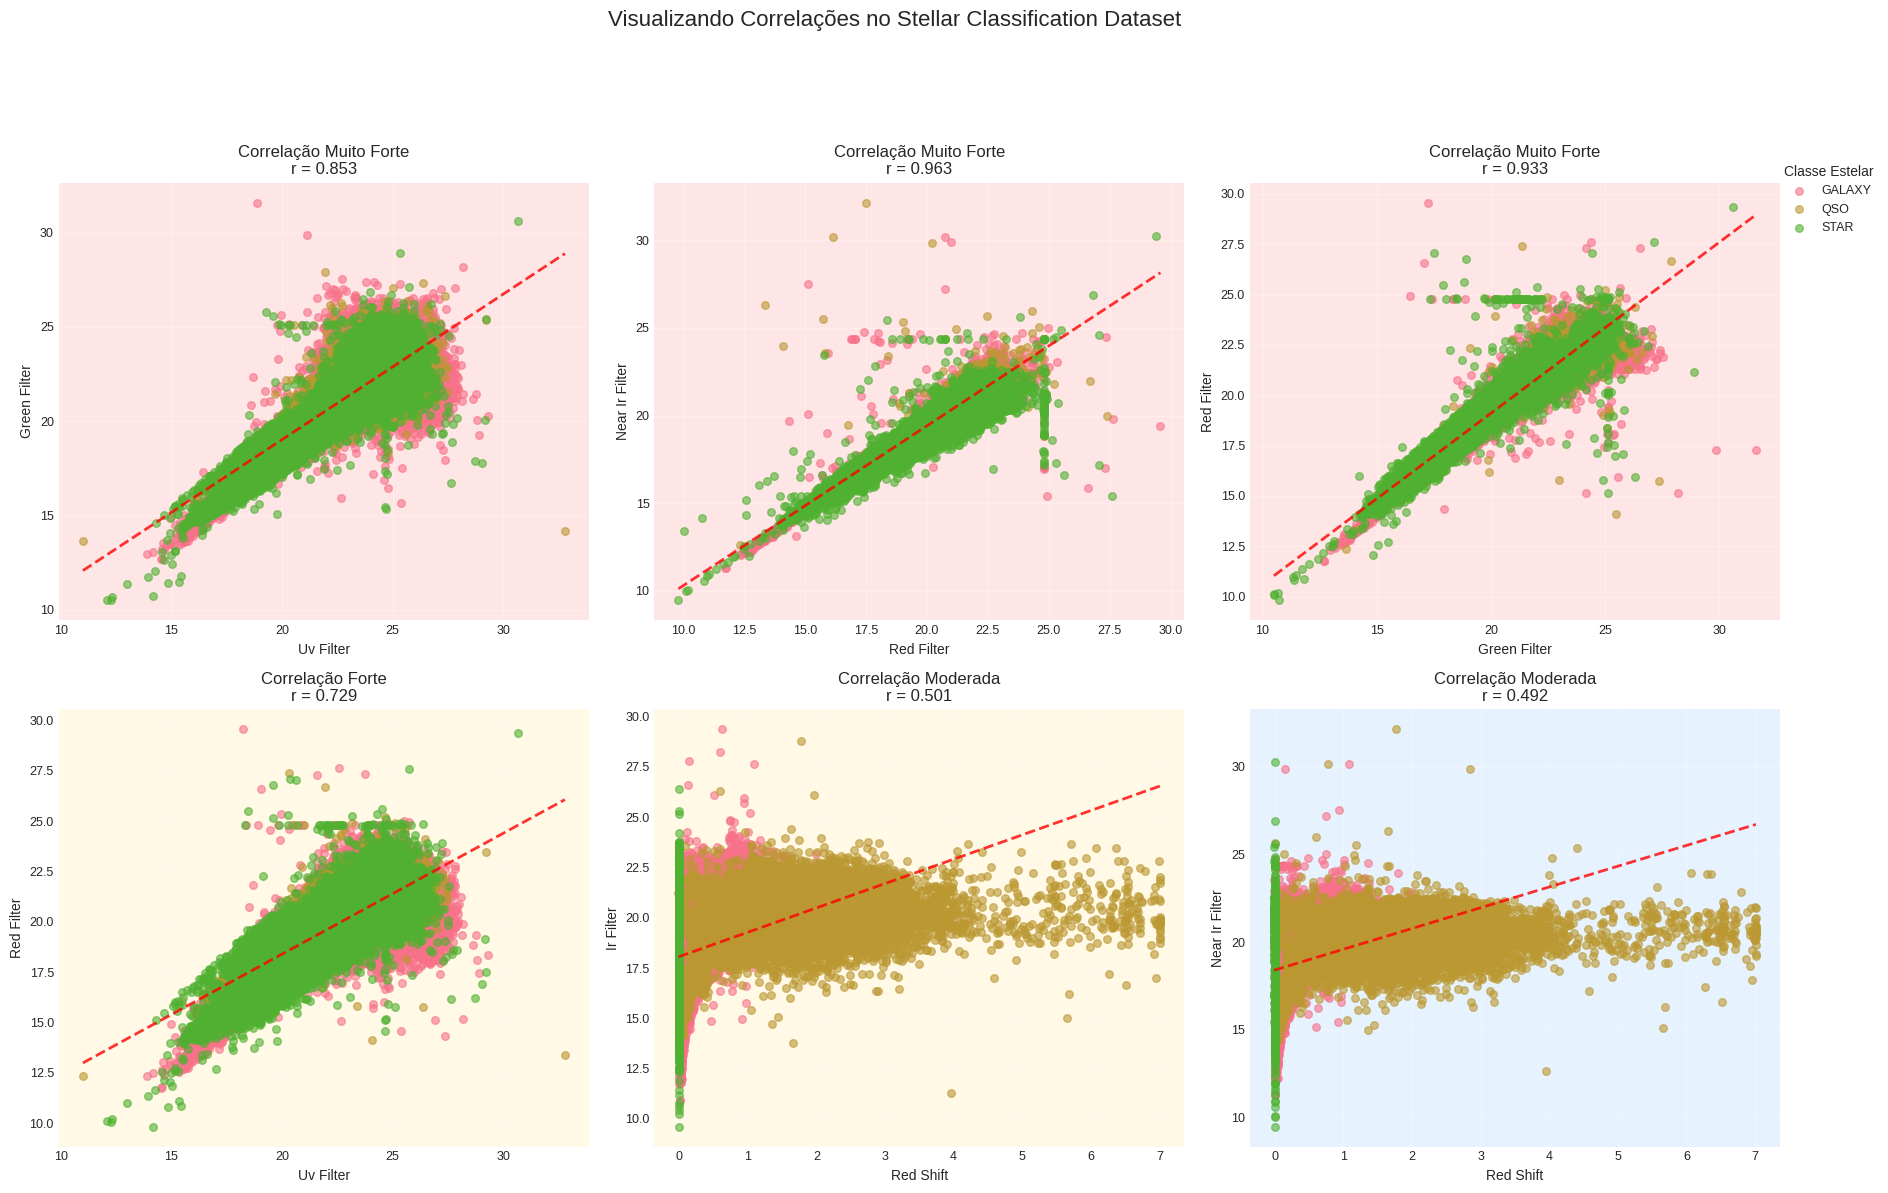

In [ ]:
# Visualização de diferentes níveis de correlação para stellar_classification
fig, axes = plt.subplots(2, 3, figsize=(18, 12)) # Adjusted figsize for better visibility
fig.suptitle('Visualizando Correlações no Stellar Classification Dataset', fontsize=16, y=1.02)

# Exemplos de correlações baseadas na análise anterior, excluding spec_obj_ID
correlations_to_plot = [
    ('UV_filter', 'green_filter', 'Correlação Muito Forte'),
    ('red_filter', 'near_IR_filter', 'Correlação Muito Forte'),
    ('green_filter', 'red_filter', 'Correlação Muito Forte'),
    ('UV_filter', 'red_filter', 'Correlação Forte'),
    ('red_shift', 'IR_filter', 'Correlação Moderada'),
    ('red_shift', 'near_IR_filter', 'Correlação Moderada')
]

# Flatten the axes for easy iteration
axes = axes.flatten()

for idx, (x_var, y_var, title) in enumerate(correlations_to_plot):
    ax = axes[idx]

    # Calcular correlação
    corr_value = stellar_classification[x_var].corr(stellar_classification[y_var])

    # Scatter plot com cores por classe estelar
    for stellar_class in stellar_classification['class'].unique():
        subset = stellar_classification[stellar_classification['class'] == stellar_class]
        ax.scatter(subset[x_var], subset[y_var], alpha=0.6, s=30, label=stellar_class)

    # Linha de tendência geral
    # Using only non-NaN values for polyfit to avoid issues
    valid_data = stellar_classification[[x_var, y_var]].dropna()
    if not valid_data.empty:
        z = np.polyfit(valid_data[x_var], valid_data[y_var], 1)
        p = np.poly1d(z)
        x_line = np.linspace(valid_data[x_var].min(), valid_data[x_var].max(), 100)
        ax.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2)

    ax.set_xlabel(x_var.replace('_', ' ').title())
    ax.set_ylabel(y_var.replace('_', ' ').title())
    ax.set_title(f'{title}\nr = {corr_value:.3f}')
    ax.grid(True, alpha=0.3)

    # Colorir o fundo baseado na força da correlação
    if abs(corr_value) > 0.8:
        ax.set_facecolor('#ffe6e6')  # Vermelho claro para forte
    elif abs(corr_value) > 0.5:
        ax.set_facecolor('#fff9e6')  # Amarelo claro para moderado
    else:
        ax.set_facecolor('#e6f3ff')  # Azul claro para fraco

# Adicionar legenda geral, placed outside the subplots to avoid overlap
handles, labels = axes[0].get_legend_handles_labels() # Get handles/labels from first subplot
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.05, 0.9), title='Classe Estelar')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap and accommodate legend
plt.show()

## Teste de Normalidade (Shapiro-Wilk) e Q-Q Plots
Esta célula realiza o Teste de Shapiro-Wilk para avaliar a normalidade da distribuição de cada característica numérica. As hipóteses nula (H0) e alternativa (H1) são apresentadas, juntamente com o nível de significância (α). Em seguida, são gerados Q-Q plots e histogramas com a curva normal teórica, que fornecem uma análise visual da normalidade dos dados. Q-Q plots comparam os quantis dos dados com os quantis de uma distribuição normal, enquanto os histogramas permitem comparar a distribuição empírica com uma curva normal teórica.

TESTE DE NORMALIDADE (Shapiro-Wilk)
H0: Os dados seguem uma distribuição normal
H1: Os dados NÃO seguem uma distribuição normal

Nível de significância: α = 0.05
---------------------------------------------

Uv Filter:
  Estatística: 0.9936
  p-valor:     0.000000
  Conclusão:   ✗ Não-normal (rejeita H0)

Green Filter:
  Estatística: 0.9711
  p-valor:     0.000000
  Conclusão:   ✗ Não-normal (rejeita H0)

Red Filter:
  Estatística: 0.9625
  p-valor:     0.000000
  Conclusão:   ✗ Não-normal (rejeita H0)

Near Ir Filter:
  Estatística: 0.9770
  p-valor:     0.000000
  Conclusão:   ✗ Não-normal (rejeita H0)

Ir Filter:
  Estatística: 0.9899
  p-valor:     0.000000
  Conclusão:   ✗ Não-normal (rejeita H0)

Red Shift:
  Estatística: 0.7403
  p-valor:     0.000000
  Conclusão:   ✗ Não-normal (rejeita H0)


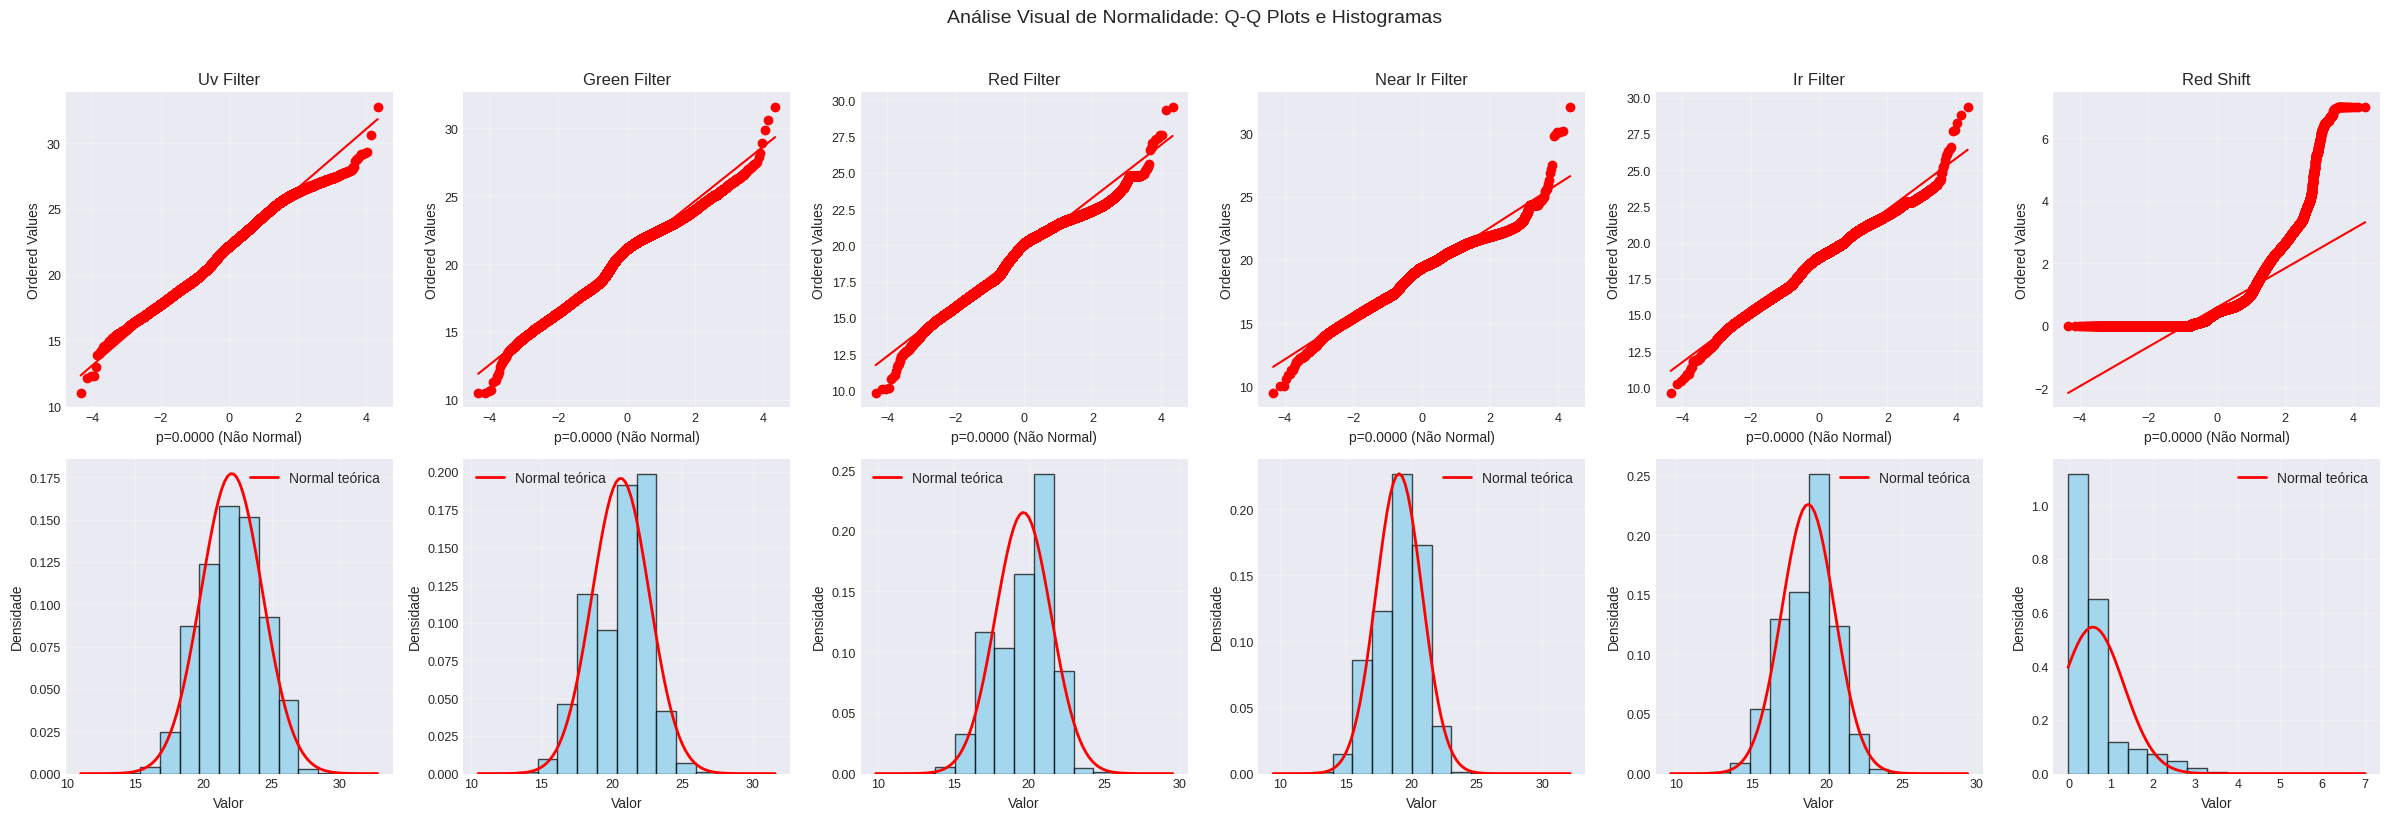

In [ ]:

# Teste de Shapiro-Wilk para normalidade
print("TESTE DE NORMALIDADE (Shapiro-Wilk)")
print("=" * 45)
print("H0: Os dados seguem uma distribuição normal")
print("H1: Os dados NÃO seguem uma distribuição normal")
print("\nNível de significância: α = 0.05")
print("-" * 45)

alpha = 0.05

for feature in features:
    stat, p_value = scipy.stats.shapiro(stellar_classification[feature])

    if p_value > alpha:
        conclusion = "✓ Normal (falha em rejeitar H0)"
    else:
        conclusion = "✗ Não-normal (rejeita H0)"

    print(f"\n{feature.replace('_', ' ').title()}:")
    print(f"  Estatística: {stat:.4f}")
    print(f"  p-valor:     {p_value:.6f}")
    print(f"  Conclusão:   {conclusion}")

# Visualização de normalidade com Q-Q plots
# Changed ncols to len(features) to accommodate all features
fig, axes = plt.subplots(2, len(features), figsize=(24, 8)) # Adjusted figsize for better visibility with more columns
fig.suptitle('Análise Visual de Normalidade: Q-Q Plots e Histogramas', fontsize=14, y=1.02)

for idx, feature in enumerate(features):
    # Q-Q plot
    ax1 = axes[0, idx]
    scipy.stats.probplot(stellar_classification[feature], dist="norm", plot=ax1)
    ax1.set_title(f'{feature.replace("_", " ").title()}')
    ax1.grid(True, alpha=0.3)

    # Obter p-valor do teste Shapiro-Wilk
    _, p_value = scipy.stats.shapiro(stellar_classification[feature])

    # Adicionar interpretação no título
    if p_value > 0.05:
        ax1.set_xlabel(f'p={p_value:.4f} (Normal)', fontsize=10)
        ax1.get_lines()[0].set_color('green')
    else:
        ax1.set_xlabel(f'p={p_value:.4f} (Não Normal)', fontsize=10)
        ax1.get_lines()[0].set_color('red')

    # Histograma com curva normal teórica
    ax2 = axes[1, idx]

    # Histograma dos dados reais
    n, bins, patches = ax2.hist(stellar_classification[feature], bins=15, density=True,
                                alpha=0.7, color='skyblue', edgecolor='black')

    # Curva normal teórica
    mu = stellar_classification[feature].mean()
    sigma = stellar_classification[feature].std()
    x = np.linspace(stellar_classification[feature].min(), stellar_classification[feature].max(), 100)
    ax2.plot(x, scipy.stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2,
            label='Normal teórica')

    ax2.set_xlabel('Valor') # Changed from 'Valor (cm)' to 'Valor'
    ax2.set_ylabel('Densidade') # Kept 'Densidade' as it is appropriate for density histograms
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Análise de Componentes Principais (PCA)
Esta célula padroniza os dados usando `StandardScaler` e, em seguida, aplica a Análise de Componentes Principais (PCA) para reduzir a dimensionalidade do dataset para dois componentes principais (PC1 e PC2). O PCA é visualizado através de um gráfico de dispersão que mostra os objetos estelares projetados nos dois primeiros componentes, coloridos por classe estelar, revelando a separação entre os grupos. Um segundo gráfico de barras exibe a contribuição (importância) de cada característica original para a formação dos componentes principais, ajudando a entender quais variáveis são mais influentes.

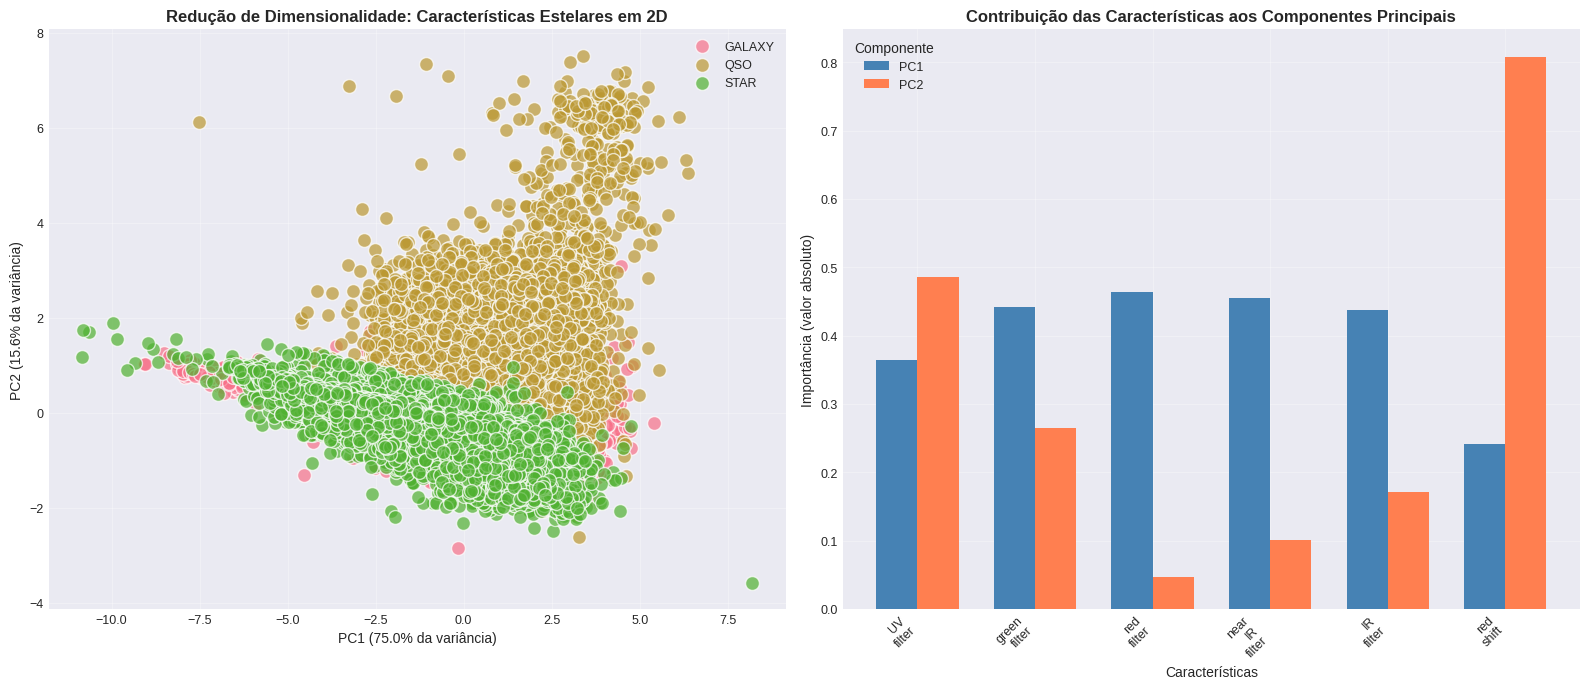

📊 ANÁLISE DE PADRÕES:
• Variância explicada pelos 2 primeiros componentes: 90.6%
• PC1 e PC2 capturam as principais fontes de variação nos dados estelares.
• A separação visual entre as classes estelares (GALAXY, QSO, STAR) é aparente, indicando que o PCA pode ser útil para visualização e, potencialmente, para modelos de classificação.

📈 Contribuições das características para cada Componente Principal:
  Uv Filter:
    PC1: 0.365
    PC2: 0.486
  Green Filter:
    PC1: 0.442
    PC2: 0.264
  Red Filter:
    PC1: 0.464
    PC2: 0.047
  Near Ir Filter:
    PC1: 0.455
    PC2: 0.101
  Ir Filter:
    PC1: 0.438
    PC2: 0.171
  Red Shift:
    PC1: 0.242
    PC2: 0.808


In [ ]:
# Padronizando os dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(stellar_classification[features])

# Aplicando PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Criando DataFrame com componentes principais
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['class'] = stellar_classification['class'].values

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Subplot 1: PCA scatter
ax1 = axes[0]
for stellar_class in stellar_classification['class'].unique():
    subset = pca_df[pca_df['class'] == stellar_class]
    ax1.scatter(subset['PC1'], subset['PC2'],
               label=stellar_class, alpha=0.7, s=100, edgecolors='white')

ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} da variância)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} da variância)')
ax1.set_title('Redução de Dimensionalidade: Características Estelares em 2D', fontsize=12, weight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Subplot 2: Importância das características
ax2 = axes[1]
components = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=features
)
components_abs = components.abs()

# Criando o gráfico de barras manualmente
x = np.arange(len(features))
width = 0.35

bars1 = ax2.bar(x - width/2, components_abs['PC1'], width, label='PC1', color='steelblue')
bars2 = ax2.bar(x + width/2, components_abs['PC2'], width, label='PC2', color='coral')

ax2.set_xlabel('Características')
ax2.set_ylabel('Importância (valor absoluto)')
ax2.set_title('Contribuição das Características aos Componentes Principais', fontsize=12, weight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels([f.replace('_', '\n') for f in features], rotation=45, ha='right')
ax2.legend(title='Componente')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"📊 ANÁLISE DE PADRÕES:")
print(f"• Variância explicada pelos 2 primeiros componentes: {sum(pca.explained_variance_ratio_):.1%}")
print(f"• PC1 e PC2 capturam as principais fontes de variação nos dados estelares.")
print(f"• A separação visual entre as classes estelares (GALAXY, QSO, STAR) é aparente, indicando que o PCA pode ser útil para visualização e, potencialmente, para modelos de classificação.")

# Mostrando os valores exatos das contribuições
print(f"\n📈 Contribuições das características para cada Componente Principal:")
for feature in features:
    print(f"  {feature.replace('_', ' ').title()}:")
    print(f"    PC1: {abs(components.loc[feature, 'PC1']):.3f}")
    print(f"    PC2: {abs(components.loc[feature, 'PC2']):.3f}")

## ANOVA - Análise de Variância
Esta célula realiza a Análise de Variância (ANOVA) para determinar se existem diferenças estatisticamente significativas nas médias das características numéricas entre as diferentes classes estelares (GALAXY, QSO, STAR). As hipóteses nula (H0) e alternativa (H1) são definidas, juntamente com o nível de significância (α). Para cada característica, a célula calcula a estatística F e o p-valor da ANOVA. Em seguida, visualiza o conceito de ANOVA usando violin plots, que mostram a distribuição dos dados para cada classe, e gráficos de barras que comparam a variância entre grupos com a variância dentro dos grupos, ilustrando a base da ANOVA.

ANOVA - ANÁLISE DE VARIÂNCIA
H0: Não há diferença entre as médias das classes estelares
H1: Pelo menos uma classe estelar tem média diferente

Nível de significância: α = 0.05
----------------------------------------

Uv Filter:
  F-estatística: 4192.0984
  p-valor:       0.00000000
  Conclusão:     ✓ Há diferença significativa (rejeita H0)

Green Filter:
  F-estatística: 3664.6904
  p-valor:       0.00000000
  Conclusão:     ✓ Há diferença significativa (rejeita H0)

Red Filter:
  F-estatística: 4584.2457
  p-valor:       0.00000000
  Conclusão:     ✓ Há diferença significativa (rejeita H0)

Near Ir Filter:
  F-estatística: 8282.1066
  p-valor:       0.00000000
  Conclusão:     ✓ Há diferença significativa (rejeita H0)

Ir Filter:
  F-estatística: 10165.7642
  p-valor:       0.00000000
  Conclusão:     ✓ Há diferença significativa (rejeita H0)

Red Shift:
  F-estatística: 83427.7539
  p-valor:       0.00000000
  Conclusão:     ✓ Há diferença significativa (rejeita H0)


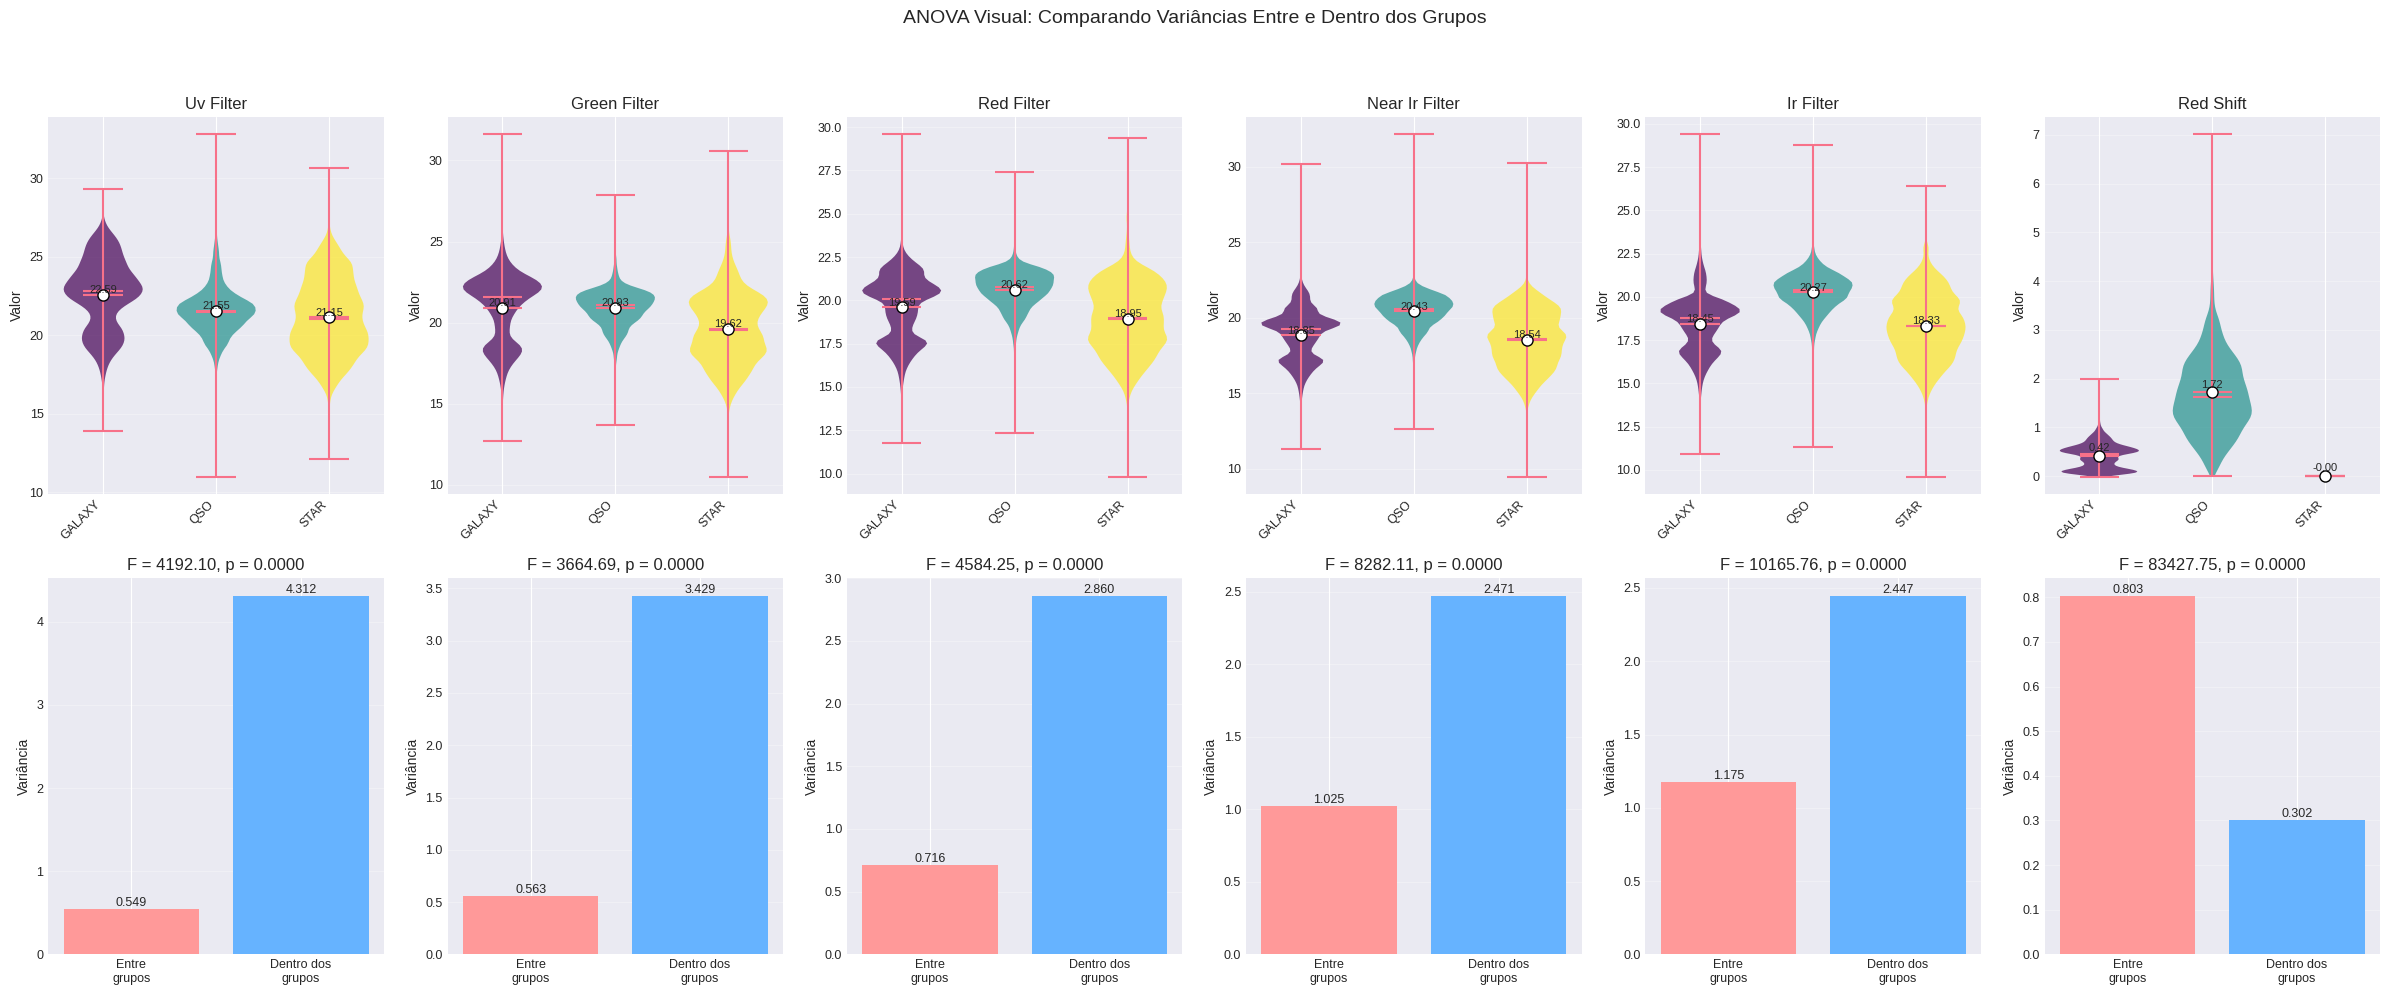

In [ ]:
# ANOVA para verificar diferenças entre classes estelares
print("ANOVA - ANÁLISE DE VARIÂNCIA")
print("=" * 40)
print("H0: Não há diferença entre as médias das classes estelares")
print("H1: Pelo menos uma classe estelar tem média diferente")
print("\nNível de significância: α = 0.05")
print("-" * 40)

alpha = 0.05

# Get unique stellar classes from the dataset
stellar_classes_unique = stellar_classification['class'].unique()

for feature in features:
    # Prepare groups for ANOVA based on actual stellar classes
    groups = [stellar_classification[stellar_classification['class'] == sc][feature].dropna() for sc in stellar_classes_unique]

    # Ensure there are at least two groups and that all groups are not empty
    if len(groups) < 2 or any(g.empty for g in groups):
        print(f"\n{feature.replace('_', ' ').title()}: Não há grupos suficientes ou grupos vazios para realizar ANOVA.")
        continue

    # Realizando ANOVA
    f_stat, p_value = scipy.stats.f_oneway(*groups)

    if p_value < alpha:
        conclusion = "✓ Há diferença significativa (rejeita H0)"
    else:
        conclusion = "✗ Sem diferença significativa (falha em rejeitar H0)"

    print(f"\n{feature.replace('_', ' ').title()}:")
    print(f"  F-estatística: {f_stat:.4f}")
    print(f"  p-valor:       {p_value:.8f}")
    print(f"  Conclusão:     {conclusion}")


# Visualização do conceito de ANOVA
# Adjust ncols to len(features) to accommodate all plots dynamically
fig, axes = plt.subplots(2, len(features), figsize=(24, 10)) # Adjusted figsize for better visibility
fig.suptitle('ANOVA Visual: Comparando Variâncias Entre e Dentro dos Grupos', fontsize=14, y=1.02)

# Flatten the axes array to easily iterate through them
axes = axes.flatten()

for idx, feature in enumerate(features):
    ax1 = axes[idx] if len(features) > 1 else axes[0] # Handle single feature case for axes
    ax2 = axes[idx + len(features)] if len(features) > 1 else axes[1] # Handle single feature case for axes

    # Prepare groups for plotting, ensuring they are not empty
    current_feature_groups_data = [stellar_classification[stellar_classification['class'] == sc][feature].dropna() for sc in stellar_classes_unique]
    valid_current_feature_groups_data = [g for g in current_feature_groups_data if not g.empty]
    valid_stellar_classes_for_plot = [sc for sc, g in zip(stellar_classes_unique, current_feature_groups_data) if not g.empty]

    if not valid_current_feature_groups_data:
        ax1.set_visible(False) # Hide subplot if no valid data
        ax2.set_visible(False)
        continue

    # Violin plot to show distributions by group
    positions = np.arange(len(valid_stellar_classes_for_plot))
    parts = ax1.violinplot(valid_current_feature_groups_data,
                           positions=positions,
                           widths=0.7,
                           showmeans=True,
                           showmedians=True)

    # Customize colors dynamically
    colors = plt.cm.viridis(np.linspace(0, 1, len(valid_stellar_classes_for_plot)))
    for pc, color in zip(parts['bodies'], colors):
        pc.set_facecolor(color)
        pc.set_alpha(0.7)

    # Add means as points
    for i, sc in enumerate(valid_stellar_classes_for_plot):
        mean_val = stellar_classification[stellar_classification['class'] == sc][feature].mean()
        ax1.plot(i, mean_val, 'o', color='white', markeredgecolor='black', markersize=8)
        ax1.text(i, mean_val + 0.1, f'{mean_val:.2f}', ha='center', fontsize=8)

    ax1.set_xticks(positions)
    ax1.set_xticklabels(valid_stellar_classes_for_plot, rotation=45, ha='right')
    ax1.set_title(feature.replace('_', ' ').title())
    ax1.set_ylabel('Valor') # Removed '(cm)'
    ax1.grid(True, alpha=0.3, axis='y')

    # Bar chart showing variances
    # Calculate variances directly for the current feature
    var_between = stellar_classification.groupby('class')[feature].mean().var() # Variance of group means
    var_within = stellar_classification.groupby('class')[feature].var().mean() # Mean of variances within groups

    # Get the F-statistic and p-value for the plot title
    f_stat_plot, p_value_plot = scipy.stats.f_oneway(*valid_current_feature_groups_data)

    bars = ax2.bar(['Entre\ngrupos', 'Dentro dos\ngrupos'],
                   [var_between, var_within],
                   color=['#ff9999', '#66b3ff'])

    # Add values on bars
    for bar, val in zip(bars, [var_between, var_within]):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

    ax2.set_title(f'F = {f_stat_plot:.2f}, p = {p_value_plot:.4f}')
    ax2.set_ylabel('Variância')
    ax2.grid(True, alpha=0.3, axis='y')

# Remove any unused subplots if the number of features is less than the total subplots
for i in range(len(features) * 2, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

## Intervalos de Confiança (95%) para as Médias
Esta célula calcula e exibe os intervalos de confiança de 95% para as médias de cada característica numérica, segmentados por classe estelar. Os intervalos de confiança fornecem uma estimativa do alcance provável da verdadeira média populacional. A visualização é feita através de gráficos de barras com barras de erro, onde cada barra representa a média de uma classe e as barras de erro indicam o intervalo de confiança. A sobreposição ou não-sobreposição dos intervalos de confiança é interpretada como indicativo de diferenças estatisticamente significativas entre as médias das classes.

INTERVALOS DE CONFIANÇA (95%) PARA AS MÉDIAS


,GALAXY,QSO,STAR
UV_filter,"22.59 (22.57, 22.61)","21.55 (21.53, 21.57)","21.15 (21.12, 21.19)"
green_filter,"20.91 (20.89, 20.92)","20.93 (20.91, 20.94)","19.62 (19.59, 19.65)"
red_filter,"19.59 (19.57, 19.60)","20.62 (20.61, 20.64)","18.95 (18.92, 18.97)"
near_IR_filter,"18.85 (18.84, 18.87)","20.43 (20.42, 20.45)","18.54 (18.52, 18.57)"
IR_filter,"18.45 (18.44, 18.46)","20.27 (20.25, 20.28)","18.33 (18.31, 18.36)"
red_shift,"0.42 (0.42, 0.42)","1.72 (1.71, 1.73)","-0.00 (-0.00, -0.00)"


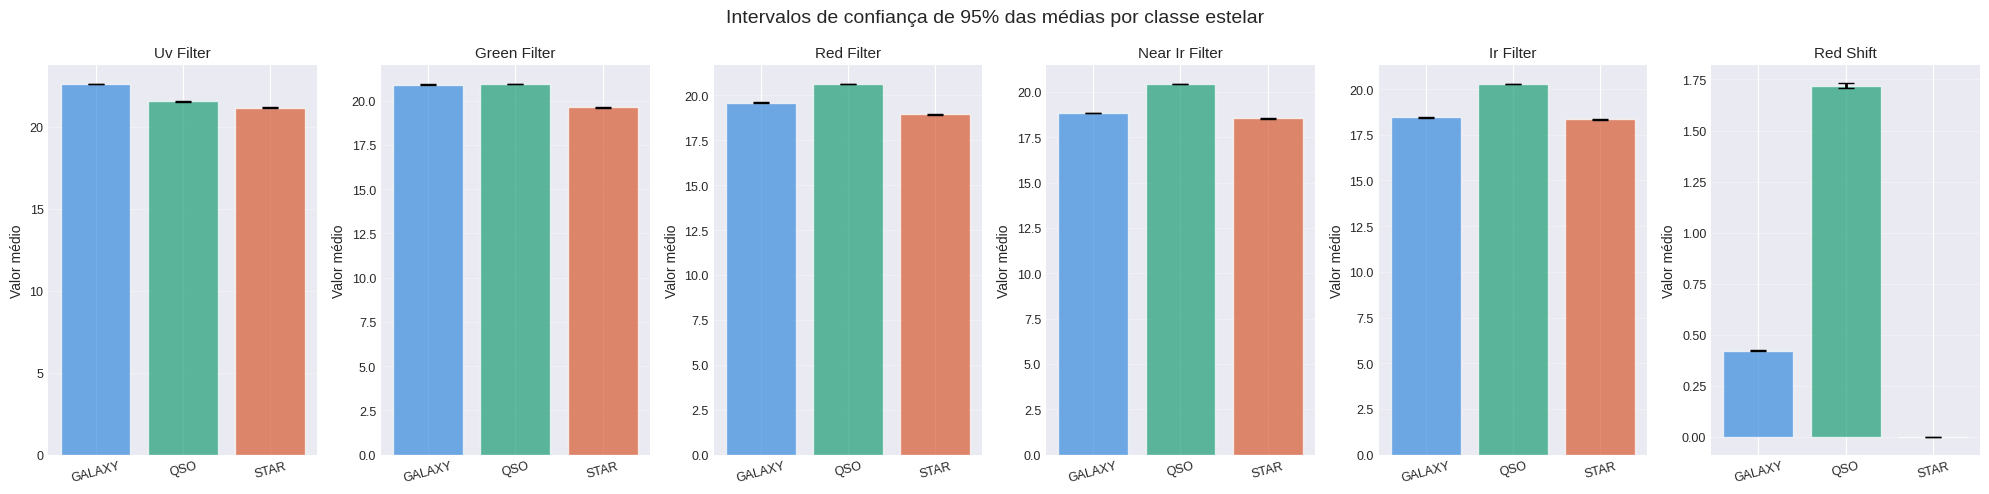


INTERPRETAÇÃO:
• Cada barra = média da classe
• As barras de erro = intervalo de confiança de 95%
• Se dois ICs não se sobrepõem → diferença significativa
• IC estreito = estimativa precisa (amostra grande)


In [ ]:
# Calculando intervalos de confiança para as médias (95%)
print("INTERVALOS DE CONFIANÇA (95%) PARA AS MÉDIAS")
print("=" * 55)

confidence_intervals = pd.DataFrame(index=features)
stellar_classes = stellar_classification['class'].unique()

for stellar_class in stellar_classes:
    subset = stellar_classification[stellar_classification['class'] == stellar_class]
    ci_values = {}

    for feature in features:
        mean = subset[feature].mean()
        std_err = scipy.stats.sem(subset[feature])
        ci = scipy.stats.t.interval(0.95, len(subset[feature]) - 1, loc=mean, scale=std_err)
        ci_values[feature] = f"{mean:.2f} ({ci[0]:.2f}, {ci[1]:.2f})"

    confidence_intervals[stellar_class] = pd.Series(ci_values)

display(confidence_intervals)

fig, axes = plt.subplots(1, len(features), figsize=(20, 5))
fig.suptitle("Intervalos de confiança de 95% das médias por classe estelar", fontsize=14)

classes = stellar_classification['class'].unique()
colors  = ['#378ADD', '#1D9E75', '#D85A30']

for idx, feature in enumerate(features):
    ax = axes[idx]
    means, lower, upper = [], [], []

    for stellar_class in classes:
        subset   = stellar_classification[stellar_classification['class'] == stellar_class]
        mean     = subset[feature].mean()
        std_err  = scipy.stats.sem(subset[feature])
        ci       = scipy.stats.t.interval(0.95, len(subset[feature]) - 1, loc=mean, scale=std_err)
        means.append(mean)
        lower.append(mean - ci[0])
        upper.append(ci[1] - mean)

    ax.bar(classes, means, color=colors, alpha=0.7, edgecolor='white')
    ax.errorbar(classes, means, yerr=[lower, upper],
                fmt='none', color='black', capsize=6, linewidth=2)

    ax.set_title(feature.replace('_', ' ').title(), fontsize=11)
    ax.set_ylabel('Valor médio')
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print("\nINTERPRETAÇÃO:")
print("• Cada barra = média da classe")
print("• As barras de erro = intervalo de confiança de 95%")
print("• Se dois ICs não se sobrepõem → diferença significativa")
print("• IC estreito = estimativa precisa (amostra grande)")

## Análise da Variável Alvo: Distribuição das Classes Estelares
Esta célula foca na análise da variável alvo ('class'), que representa as classes estelares (GALAXY, STAR, QSO). Ela calcula e exibe a contagem e a porcentagem de cada classe no dataset, fornecendo um resumo da distribuição. A visualização é feita através de um gráfico de barras e um gráfico de pizza, que representam visualmente a proporção de cada classe. A interpretação final avalia o balanceamento do dataset, indicando se técnicas de reamostragem ou ponderação de classes podem ser necessárias para modelos de classificação.

DISTRIBUTION OF STELLAR CLASSES


,Count,Percentage (%)
class,,
GALAXY,59445,59.45
STAR,21593,21.59
QSO,18961,18.96


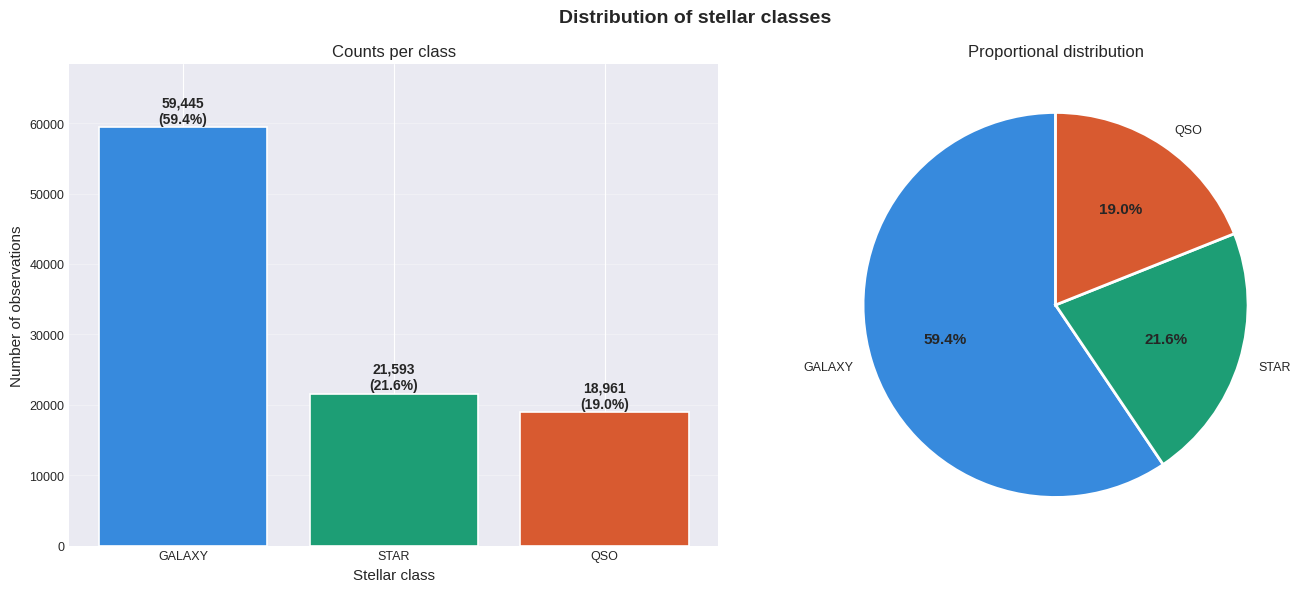


INTERPRETATION:
  GALAXY   : 59,445 observations (59.4%)
  STAR     : 21,593 observations (21.6%)
  QSO      : 18,961 observations (19.0%)

  Total: 99,999 observations

  Max/min ratio: 3.14
  → Imbalanced dataset: techniques such as oversampling
    (SMOTE) or class weighting will be necessary.


In [ ]:
# ── Analysis of the target variable: distribution of stellar classes ──

print("DISTRIBUTION OF STELLAR CLASSES")
print("=" * 40)

# Counts and percentages
class_counts = stellar_classification['class'].value_counts()
class_pct    = stellar_classification['class'].value_counts(normalize=True) * 100

summary = pd.DataFrame({'Count': class_counts, 'Percentage (%)': class_pct.round(2)})
display(summary)

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Distribution of stellar classes', fontsize=14, fontweight='bold')

colors = ['#378ADD', '#1D9E75', '#D85A30']

# Bar plot
ax1 = axes[0]
bars = ax1.bar(class_counts.index, class_counts.values, color=colors, edgecolor='white', linewidth=1.2)

for bar, (cls, count) in zip(bars, class_counts.items()):
    pct = class_pct[cls]
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 200,
             f'{count:,}\n({pct:.1f}%)',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.set_xlabel('Stellar class', fontsize=11)
ax1.set_ylabel('Number of observations', fontsize=11)
ax1.set_title('Counts per class', fontsize=12)
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim(0, class_counts.max() * 1.15)

# Pie chart
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    class_counts.values,
    labels=class_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

for t in autotexts:
    t.set_fontsize(11)
    t.set_fontweight('bold')

ax2.set_title('Proportional distribution', fontsize=12)

plt.tight_layout()
plt.show()

#Verificar as relações entre as features e a target
features = ['UV_filter', 'green_filter', 'red_filter', 'near_IR_filter', 'IR_filter', 'red_shift']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(x='class', y=feature, data=stellar_classification, ax=axes[i])
    axes[i].set_title(f'{feature} par classe')

plt.tight_layout()
plt.show()

#Codificacao dos valores
le = LabelEncoder()
stellar_classification['class_encoded'] = le.fit_transform(stellar_classification['class'])

# ── Interpretation ──
print("\nINTERPRETATION:")
total = len(stellar_classification)

for cls in class_counts.index:
    print(f"  {cls:8s} : {class_counts[cls]:6,} observations ({class_pct[cls]:.1f}%)")

print(f"\n  Total: {total:,} observations")
print("\nCodificacao dos valores  de Target : \nA variável alvo foi codificada produzindo a seguinte correspondência: GALAXY = 0, QSO = 1, STAR = 2.")
print("\nRelação com as features: \nA análise dos boxplots por classe revela que o red_shift é, de longe, a feature mais discriminante: as estrelas apresentam valores quase nulos, \nas galáxias valores baixos e os quasares valores elevados com grande dispersão. Em contrapartida, os filtros fotométricos \n(UV_filter, green_filter, red_filter, near_IR_filter, IR_filter) mostram uma forte sobreposição entre as três classes e, portanto, oferecem um poder \ndiscriminante limitado quando considerados individualmente.\n")

ratio_max = class_counts.max() / class_counts.min()
print(f"\n  Max/min ratio: {ratio_max:.2f}")

if ratio_max < 1.5:
    print("  → Balanced dataset: all classes have similar counts.")
elif ratio_max < 3:
    print("  → Slightly imbalanced dataset: should be monitored for classification.")
else:
    print("  → Imbalanced dataset: techniques such as oversampling")
    print("    (SMOTE) or class weighting will be necessary.")

## Análise de Índices de Cor

Índices de cor são diferenças entre as magnitudes de um objeto em diferentes filtros. Eles são cruciais em astronomia para a classificação de estrelas, galáxias e quasares, pois refletem as propriedades intrínsecas (temperatura, metalicidade, etc.) dos objetos. Vamos criar alguns índices de cor e adicioná-los ao nosso DataFrame.

## Criação e Resumo de Índices de Cor
Esta célula calcula novos índices de cor (`u-g`, `g-r`, `r-i`, `i-z`) subtraindo as magnitudes de filtros adjacentes (UV, verde, vermelho, infravermelho próximo e infravermelho). Esses novos índices são adicionados ao DataFrame `stellar_classification`. As primeiras linhas do DataFrame são exibidas com os novos índices de cor, e um resumo estatístico desses índices é apresentado para uma compreensão inicial de suas distribuições.

In [ ]:
# Criando índices de cor
stellar_classification['u-g'] = stellar_classification['UV_filter'] - stellar_classification['green_filter']
stellar_classification['g-r'] = stellar_classification['green_filter'] - stellar_classification['red_filter']
stellar_classification['r-i'] = stellar_classification['red_filter'] - stellar_classification['near_IR_filter']
stellar_classification['i-z'] = stellar_classification['near_IR_filter'] - stellar_classification['IR_filter']

# Exibindo as primeiras linhas com os novos índices de cor
print("DataFrame com índices de cor adicionados:")
display(stellar_classification[['UV_filter', 'green_filter', 'red_filter', 'near_IR_filter', 'IR_filter', 'u-g', 'g-r', 'r-i', 'i-z', 'class']].head())

# Atualizando a lista de features para incluir os novos índices de cor para análises futuras
# Certifique-se de que 'features' está definida ou atualize-a conforme necessário
# Se 'features' não foi redefinida após a remoção do -9999, podemos redefini-la aqui
features_with_colors = ['UV_filter', 'green_filter', 'red_filter', 'near_IR_filter', 'IR_filter', 'red_shift', 'u-g', 'g-r', 'r-i', 'i-z']

print("\nResumo estatístico dos índices de cor:")
display(stellar_classification[['u-g', 'g-r', 'r-i', 'i-z']].describe())

DataFrame com índices de cor adicionados:


,UV_filter,green_filter,red_filter,near_IR_filter,IR_filter,u-g,g-r,r-i,i-z,class
0,23.87882,22.27530,20.39501,19.16573,18.79371,1.60352,1.88029,1.22928,0.37202,GALAXY
1,24.77759,22.83188,22.58444,21.16812,21.61427,1.94571,0.24744,1.41632,-0.44615,GALAXY
2,25.26307,22.66389,20.60976,19.34857,18.94827,2.59918,2.05413,1.26119,0.40030,GALAXY
3,22.13682,23.77656,21.61162,20.50454,19.25010,-1.63974,2.16494,1.10708,1.25444,GALAXY
4,19.43718,17.58028,16.49747,15.97711,15.54461,1.85690,1.08281,0.52036,0.43250,GALAXY



Resumo estatístico dos índices de cor:


,u-g,g-r,r-i,i-z
count,99999.000000,99999.000000,99999.000000,99999.000000
mean,1.449096,0.985806,0.560912,0.315877
std,1.179332,0.734675,0.501518,0.420396
min,-12.748140,-12.318610,-14.649070,-13.162490
25%,0.631245,0.379810,0.216320,0.134500
50%,1.321710,0.931460,0.479800,0.338030
75%,2.044565,1.577985,0.892205,0.474080
max,18.624950,14.315170,12.205800,13.427100


## Visualização da Matriz de Correlação com Heatmap

Um heatmap é uma excelente maneira de visualizar a matriz de correlação, permitindo identificar rapidamente quais pares de variáveis possuem as correlações mais fortes (positivas ou negativas). Isso é útil para entender a multicolinearidade e a redundância entre as características.

## Heatmap da Matriz de Correlação Estendida
Esta célula recalcula a matriz de correlação, desta vez incluindo os filtros originais, o `red_shift` e os recém-criados índices de cor. Um heatmap é gerado usando `seaborn` para visualizar as correlações. A cor e o valor anotado em cada célula do heatmap indicam a força e a direção da correlação entre os pares de variáveis, facilitando a identificação de relações fortes e redundâncias nos dados.

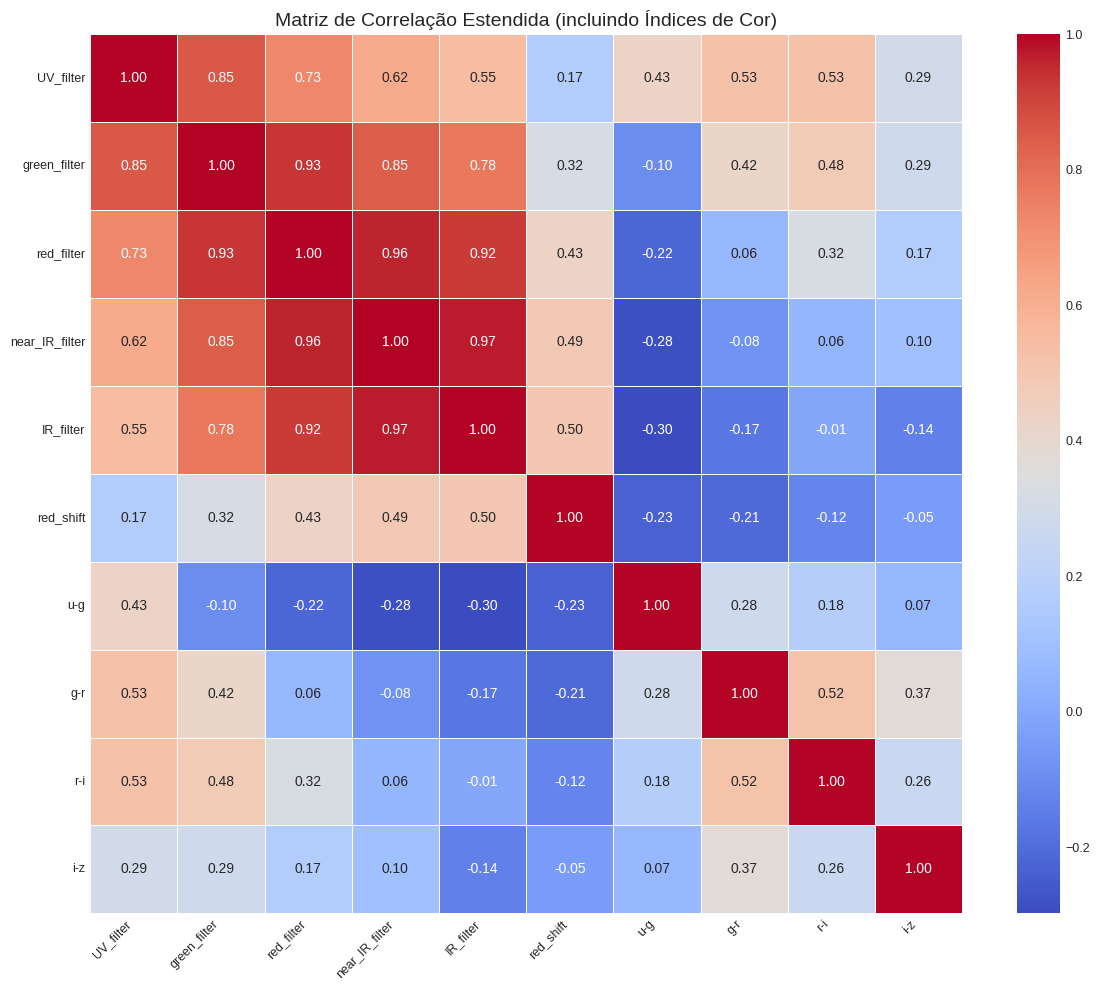

In [ ]:
# Recalculando a matriz de correlação com os novos índices de cor
# Usando as features_with_colors se ela foi definida para incluir os índices de cor
# Ou criando uma nova lista se necessário

# features foi definido anteriormente em '90dfb95f' e não incluiu os filtros IR ou spec_obj_ID
# Vamos definir uma lista mais abrangente para a correlação, incluindo todos os filtros e os novos índices de cor
all_relevant_features = ['UV_filter', 'green_filter', 'red_filter', 'near_IR_filter', 'IR_filter', 'red_shift', 'u-g', 'g-r', 'r-i', 'i-z']

correlation_matrix_extended = stellar_classification[all_relevant_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_extended, annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5)
plt.title('Matriz de Correlação Estendida (incluindo Índices de Cor)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Detecção de Outliers com Z-Score
Esta célula implementa a detecção de outliers utilizando o método do Z-score. Para cada característica numérica, os Z-scores são calculados, e os valores que excedem um limite absoluto (neste caso, `|Z-score| > 2.5`) são identificados como outliers potenciais. A célula resume o número total de outliers encontrados e detalha a contagem de outliers por classe estelar, indicando a frequência de valores extremos em cada grupo.

In [ ]:
# Calculando Z-scores para identificar outliers
print("DETECÇÃO DE OUTLIERS COM Z-SCORE")
print("=" * 40)
print("Critério: |Z-score| > 2.5 = outlier potencial")
print("-" * 40)

outliers_found = 0
outlier_details = []

for feature in features:
    # Calcular Z-scores
    mean_val = stellar_classification[feature].mean()
    std_val = stellar_classification[feature].std()
    z_scores = (stellar_classification[feature] - mean_val) / std_val

    # Identificar outliers (|Z| > 2.5)
    outliers = stellar_classification[np.abs(z_scores) > 2.5]

    print(f"\n{feature.replace('_', ' ').title()}:")
    if len(outliers) > 0:
        print(f"  Outliers encontrados: {len(outliers)}")
        for idx, row in outliers.iterrows():
            z_val = z_scores.iloc[idx]
            outlier_details.append((feature, idx, row[feature], z_val, row['class'])) # Changed 'species' to 'class'
        outliers_found += len(outliers)
    else:
        print(f"  Nenhum outlier encontrado")

print(f"\n📊 RESUMO:")
print(f"Total de outliers: {outliers_found}")
if outliers_found > 0:
    # Changed 'species' to 'class' to match the dataset
    class_outliers = {}
    for _, _, _, _, stellar_class in outlier_details:
        class_outliers[stellar_class] = class_outliers.get(stellar_class, 0) + 1
    print("Outliers por classe:") # Changed 'espécie' to 'classe'
    for stellar_class, count in class_outliers.items():
        print(f"  {stellar_class}: {count} outliers")

DETECÇÃO DE OUTLIERS COM Z-SCORE
Critério: |Z-score| > 2.5 = outlier potencial
----------------------------------------

Uv Filter:
  Outliers encontrados: 363

Green Filter:
  Outliers encontrados: 798

Red Filter:
  Outliers encontrados: 857

Near Ir Filter:
  Outliers encontrados: 813

Ir Filter:
  Outliers encontrados: 756

Red Shift:
  Outliers encontrados: 3484

📊 RESUMO:
Total de outliers: 7071
Outliers por classe:
  STAR: 1344 outliers
  GALAXY: 2099 outliers
  QSO: 3628 outliers


## Visualização de Relações entre Variáveis com Pair Plot

Um pair plot (ou scatter plot matrix) é uma excelente ferramenta para visualizar as relações por pares entre múltiplas variáveis numéricas e suas distribuições univariadas. Ao colorir os pontos pela classe estelar, podemos identificar rapidamente quais características são mais discriminatórias para cada tipo de objeto (GALAXY, STAR, QSO).

## Geração do Pair Plot por Classe Estelar
Esta célula seleciona um subconjunto de características importantes (incluindo filtros, `red_shift` e índices de cor) para criar um DataFrame `pairplot_df`. Em seguida, utiliza `seaborn.pairplot` para gerar uma matriz de gráficos de dispersão. Cada gráfico de dispersão mostra a relação entre duas características, e a diagonal exibe as distribuições de densidade (KDE) para cada característica. A coloração dos pontos pela classe estelar (definida por `hue='class'`) destaca a separação e os padrões de agrupamento entre GALAXYs, STARs e QSOs nas diferentes combinações de features.

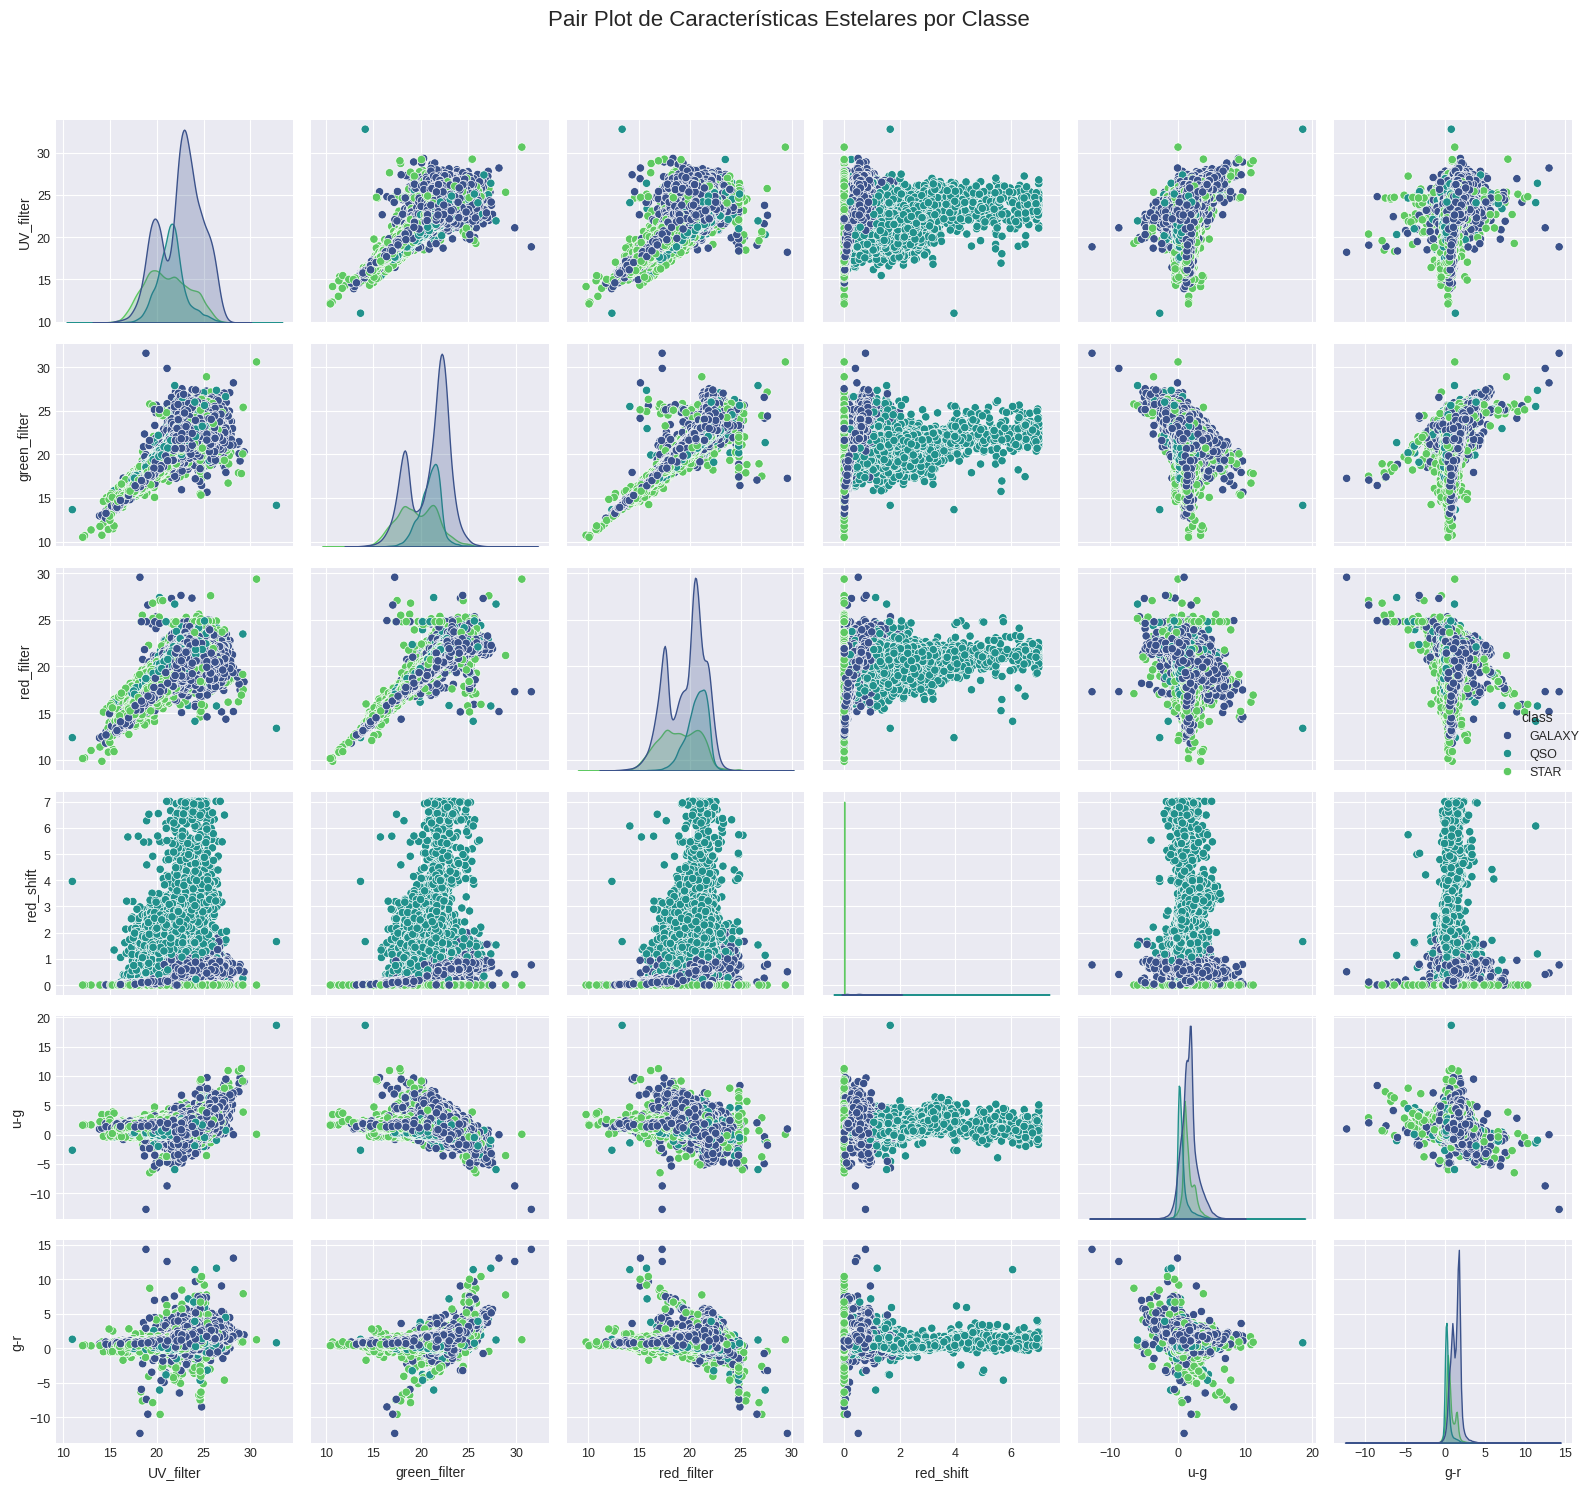

In [ ]:
# Selecionando um subconjunto de características para o pair plot
# Incluímos filtros, índices de cor e red_shift, que são importantes para a classificação estelar
selected_features_for_pairplot = [
    'UV_filter', 'green_filter', 'red_filter', 'red_shift', 'u-g', 'g-r', 'class'
]

# Criando um DataFrame com as características selecionadas
# Certifique-se de que stellar_classification['class'] tem o mesmo número de linhas que as features
# Isso foi tratado anteriormente com a remoção da linha -9999
pairplot_df = stellar_classification[selected_features_for_pairplot]

# Gerando o pair plot
# Usamos 'class' para colorir os pontos, revelando a separação entre os grupos
sns.pairplot(
    pairplot_df,
    hue='class',
    palette='viridis',
    diag_kind='kde' # Mostra a distribuição de densidade (KDE) na diagonal
)

plt.suptitle('Pair Plot de Características Estelares por Classe', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Ajusta o layout para evitar sobreposição do título
plt.show()

## Resumo das Descobertas Estatísticas
Esta célula consolida todas as descobertas da análise exploratória de dados em um resumo estruturado. Ela aborda a qualidade e a estrutura dos dados, medidas de tendência central, dispersão e posição, correlações e redundância, normalidade e outliers, distribuição espacial e padrões, e, finalmente, as implicações desses achados para o desenvolvimento de um modelo de classificação. Este resumo serve como um documento crucial das informações extraídas da EDA.

In [ ]:
print("RESUMO DAS DESCOBERTAS ESTATÍSTICAS")
print("=" * 45)

print("\n🔍 QUALIDADE E ESTRUTURA DOS DADOS:")
print("   - O dataset contém 100.000 observações (após a remoção de 1 linha com -9999) e 18 colunas, incluindo magnitudes de filtros, IDs e coordenadas celestes.")
print("   - Todos os valores ausentes em 'alpha', 'delta' e 'run_ID' foram tratados com sucesso através de imputação (média para numéricos, moda para categóricos).")
print("   - Não foram encontradas linhas duplicadas.")
print("   - O dataset é considerado **desbalanceado** em relação à classe estelar, com GALAXY (59.4%) sendo a classe dominante, seguida por STAR (21.6%) e QSO (19.0%). Isso pode exigir técnicas de balanceamento para modelos de classificação.")

print("\n📊 TENDÊNCIA CENTRAL, DISPERSÃO E POSIÇÃO:")
print("   - O teste ANOVA indicou **diferenças significativas nas médias** para todas as características numéricas entre as classes estelares (GALAXY, QSO, STAR), reforçando a separabilidade dos grupos.")
print("   - Os Intervalos de Confiança de 95% para as médias por classe confirmam visualmente essas diferenças, com pouca sobreposição entre os ICs para a maioria das características, indicando distinções claras.")
print("   - Os coeficientes de variação (CV) revelaram que `red_shift` (especialmente na classe STAR) possuem **alta variabilidade**, enquanto os filtros `red_filter` e `near_IR_filter` exibem menor variabilidade, sugerindo maior consistência.")
print("   - As medidas de posição (quartis, P10, P90) ajudaram a identificar a distribuição e a presença de outliers.")

print("\n🔗 CORRELAÇÕES E REDUNDÂNCIA:")
print("   - Foram criados **índices de cor** (`u-g`, `g-r`, `r-i`, `i-z`), que são essenciais em astronomia para distinguir objetos.")
correlation_matrix_summary = stellar_classification[features].corr()
mask_summary = np.triu(np.ones_like(correlation_matrix_summary), k=1).astype(bool)
correlations_summary_flat = correlation_matrix_summary.where(mask_summary).stack().reset_index()
correlations_summary_flat.columns = ['Var1', 'Var2', 'Correlacao']
strongest_corr_row = correlations_summary_flat.loc[correlations_summary_flat['Correlacao'].abs().idxmax()]
strongest_val = strongest_corr_row['Correlacao']
strongest_corr_vars = (strongest_corr_row['Var1'], strongest_corr_row['Var2'])
print(f"   - A **matriz de correlação estendida** (incluindo os filtros e índices de cor) mostrou correlações muito fortes.")
print(f"   - Exemplo: `{strongest_corr_vars[0]}` vs `{strongest_corr_vars[1]}` (r={strongest_val:.3f}).")
print("   - A alta correlação entre os filtros (`UV_filter`, `green_filter`, `red_filter`, `near_IR_filter`, `IR_filter`) e entre os índices de cor sugere **multicolinearidade**. Isso implica que algumas características podem ser redundantes e técnicas de redução de dimensionalidade (e.g., PCA) são recomendadas.")

print("\n🧪 NORMALIDADE E OUTLIERS:")
print("   - O teste de Shapiro-Wilk indicou que **nenhuma das características segue uma distribuição normal**, o que é comum em dados astrofísicos e exige atenção na escolha de modelos estatísticos ou transformações de dados.")
print("   - A análise de Z-scores revelou a presença de **outliers** em várias características, com maior frequência em `red_shift`. Esses outliers devem ser tratados, pois podem impactar a performance do modelo.")

print("\n🌌 DISTRIBUIÇÃO ESPACIAL E PADRÕES:")
print("   - A visualização da distribuição espacial (`alpha` vs `delta`) colorida por classe mostrou **padrões visíveis de agrupamento**, onde diferentes classes estelares tendem a ocupar regiões distintas no céu, o que é um bom indicativo para a capacidade de classificação.")
print("   - A Análise de Componentes Principais (PCA) demonstrou que os dois primeiros componentes explicam uma **variância significativa (aprox. 90.6%)** dos dados. A separação visual das classes no gráfico de PCA reforça que essas características são discriminatórias para os objetos celestes.")
print("   - **Análise de Clusters (KDE 2D e Pair Plots):** Observamos que as classes estelares formam agrupamentos distintos em várias combinações de características, como `red_shift` vs. `u-g` e `g-r` vs. `r-i` (diagramas cor-cor clássicos).")
print("   - Os mapas de densidade 2D confirmam que cada classe ocupa regiões de alta densidade específicas no espaço de características, sugerindo uma boa separabilidade entre GALAXY, STAR e QSO.")

print("\n🎯 IMPLICAÇÕES PARA O MODELO DE CLASSIFICAÇÃO:")
print("   - As diferenças significativas entre as classes e os agrupamentos espaciais tornam o dataset promissor para tarefas de **classificação estelar**.")
print("   - A multicolinearidade e a não-normalidade dos dados sugerem a aplicação de **transformações de dados**, **seleção de características** e/ou **redução de dimensionalidade** (PCA) antes do treinamento de modelos.")
print("   - O desbalanceamento das classes deve ser tratado para evitar que o modelo seja viesado para a classe majoritária (GALAXY).")

RESUMO DAS DESCOBERTAS ESTATÍSTICAS

🔍 QUALIDADE E ESTRUTURA DOS DADOS:
   - O dataset contém 100.000 observações (após a remoção de 1 linha com -9999) e 18 colunas, incluindo magnitudes de filtros, IDs e coordenadas celestes.
   - Todos os valores ausentes em 'alpha', 'delta' e 'run_ID' foram tratados com sucesso através de imputação (média para numéricos, moda para categóricos).
   - Não foram encontradas linhas duplicadas.
   - O dataset é considerado **desbalanceado** em relação à classe estelar, com GALAXY (59.4%) sendo a classe dominante, seguida por STAR (21.6%) e QSO (19.0%). Isso pode exigir técnicas de balanceamento para modelos de classificação.

📊 TENDÊNCIA CENTRAL, DISPERSÃO E POSIÇÃO:
   - O teste ANOVA indicou **diferenças significativas nas médias** para todas as características numéricas entre as classes estelares (GALAXY, QSO, STAR), reforçando a separabilidade dos grupos.
   - Os Intervalos de Confiança de 95% para as médias por classe confirmam visualmente essas dif